# Project : Bank Marketing & deposit prediction modeling
- 프로젝트 목적 : 은행 데이터를 바탕으로 최적 마케팅 파악 & deposit 이진분류 예측 모델 개발
- 데이터 정보
    - 규모 : 11200 rows * 17 columns
    - 기간 : ???
    - 출처 : [(Kaggle) Bank Marketing Dataset](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset/data)
- 최종 수정 : 2026-04-02

## 라이브러리 import

In [720]:
# 데이터 처리
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
## 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 모델링 (분류)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

# 그 외
# 경고 무시
import warnings
warnings.filterwarnings("ignore")

# 시스템
import os
import gc

## 데이터 로드 & 탐색

In [721]:
# 데이터 불러오기
PATH = "C:\\Users\\user\\Desktop\\work\\project\\bank-marketing-analysis\\data\\raw\\"

df = pd.read_csv(f"{PATH}bank.csv")
print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


칼럼 정리
- campaign : 이번 접촉(연락) 횟수
- pdays : 마지막 연락으로 부터 지난 일수
- previous : 현재 캠페인 이전 접촉(연락) 횟수
- poutcome : 이전 마케팅 성공여부

확인 필요
- month, day : 마지막 연락 월일
- duration : contact 했을 시 통화시간

In [722]:
# 데이터 확인
print("============= info =============")
print(df.info(), "\n")
print("============= describe =============")
print(df.describe(), "\n")
print("============= null sum =============")
print(df.isnull().sum())
print("total Null:", df.isnull().sum().sum(), "\n")

============= info =============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
None 

============= describe =============
                age   

In [723]:
# 범주형 변수의 고유값과 빈도 확인
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"============= {col} value_counts =============")
    print(df[col].value_counts(), "\n")

============= job value_counts =============
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64 

============= marital value_counts =============
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64 

============= education value_counts =============
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64 

============= default value_counts =============
default
no     10994
yes      168
Name: count, dtype: int64 

============= housing value_counts =============
housing
no     5881
yes    5281
Name: count, dtype: int64 

============= loan value_counts =============
loan
no     9702
yes    1460
Name: count, dtype: int64 

============= contact value_counts ====

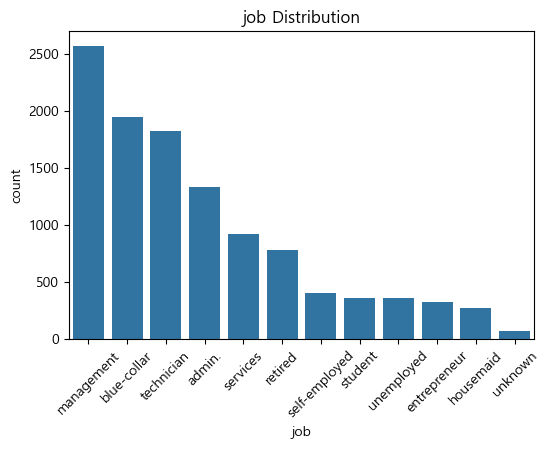

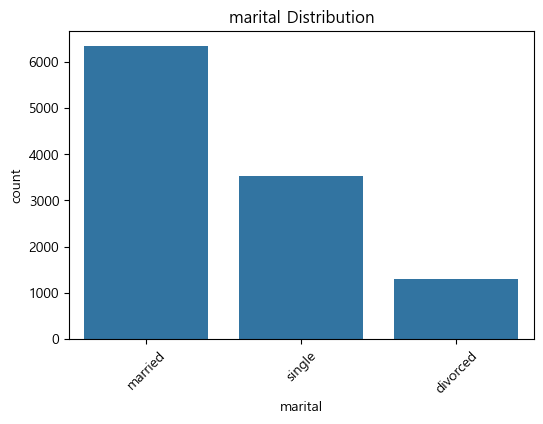

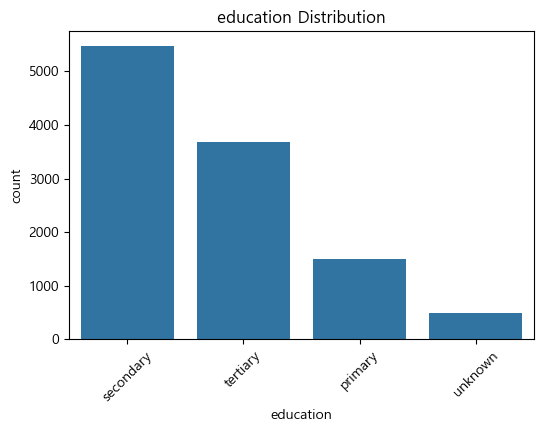

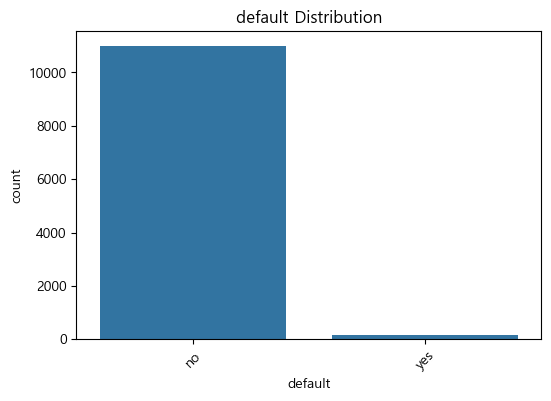

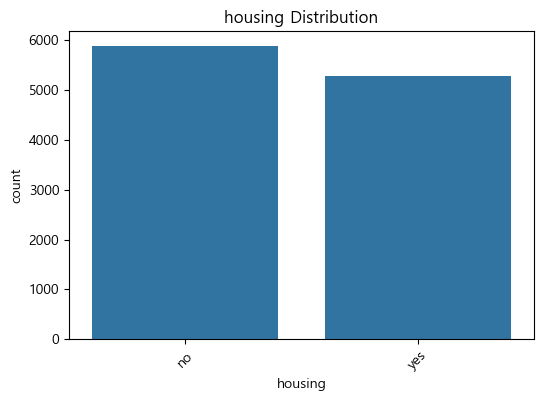

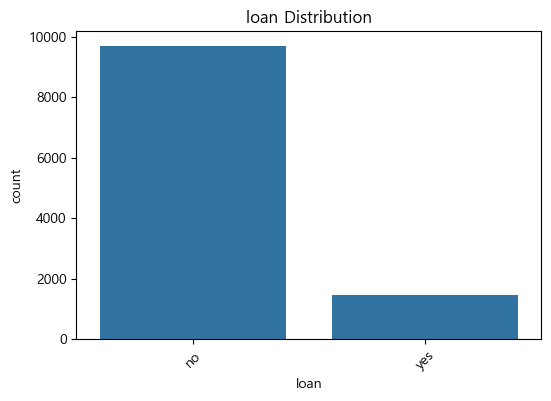

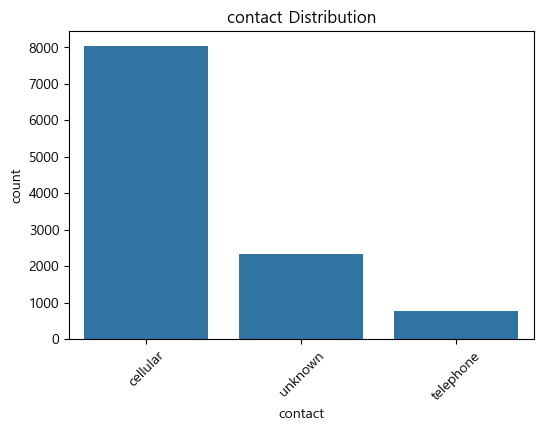

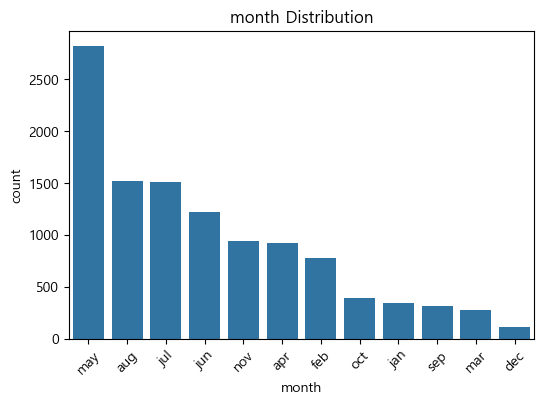

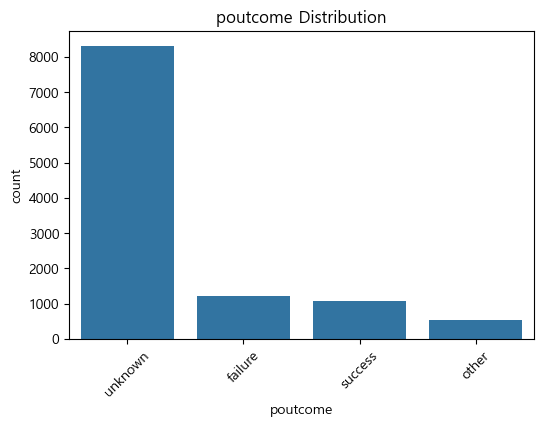

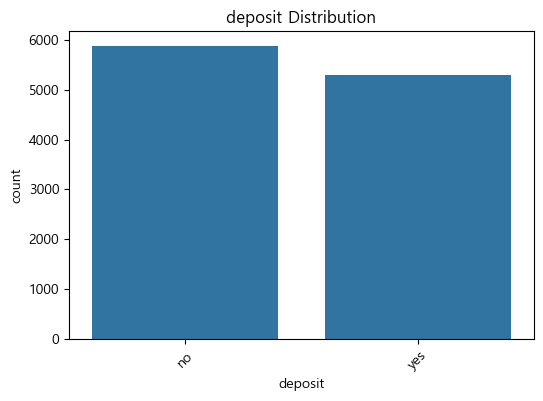

In [724]:
# 범주형 변수의 분포 확인
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()

In [725]:
# 숫자형 변수의 고유값과 빈도 확인
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    print(f"============= {col} distribution =============")
    print(df[col].describe(), "\n")

============= age distribution =============
count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64 

============= balance distribution =============
count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64 

============= day distribution =============
count    11162.000000
mean        15.658036
std          8.420740
min          1.000000
25%          8.000000
50%         15.000000
75%         22.000000
max         31.000000
Name: day, dtype: float64 

============= duration distribution =============
count    11162.000000
mean       371.993818
std        347.128386
min          2.000000
25%        138.000000
50%        255.000000
75%        496.000000
max       3881.000000
Name: duration, dty

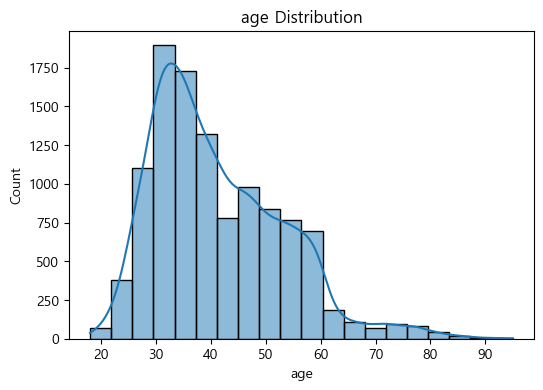

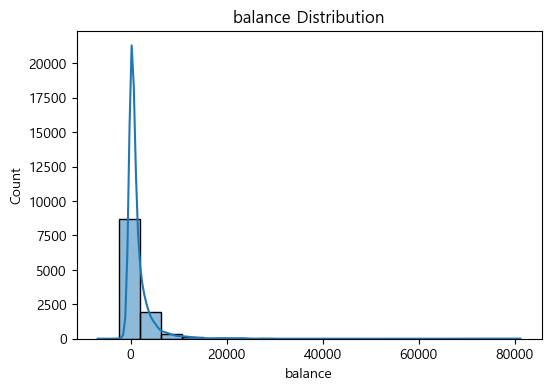

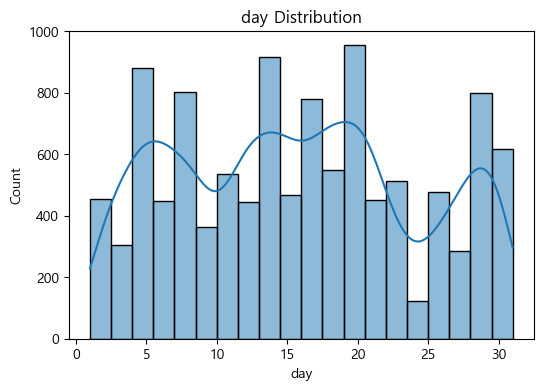

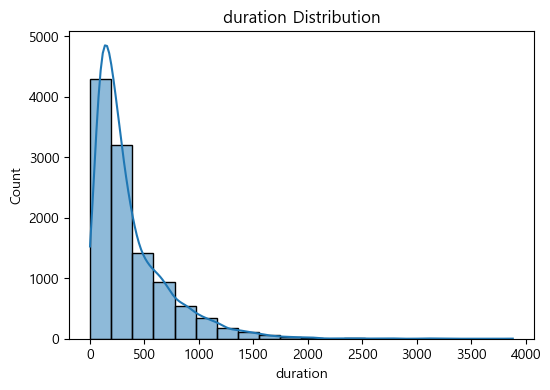

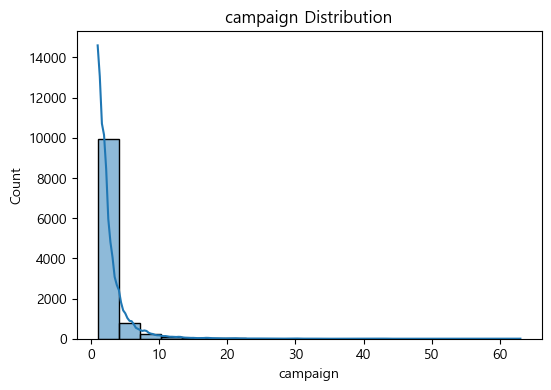

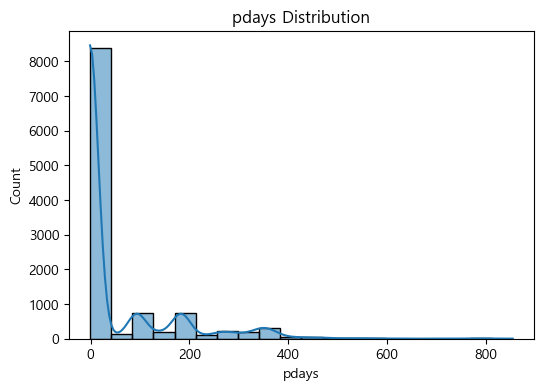

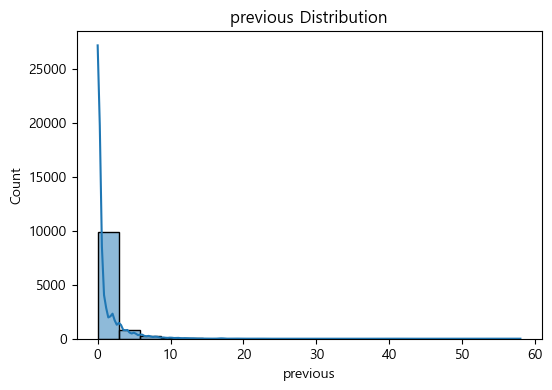

In [726]:
# 숫자형 변수의 분포 확인
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"{col} Distribution")
    plt.show()

In [727]:
# 숫자형 변수의 이상치 확인 (IQR 기준)
def check_outliers_iqr(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    outlier_mask = (df[column] < q1 - 1.5 * iqr) | (df[column] > q3 + 1.5 * iqr)
    return outlier_mask.sum()

for col in numeric_cols:
    outliers = check_outliers_iqr(df, col)
    print(f"{col} column IQR 기준 이상치: {outliers}건")

age column IQR 기준 이상치: 171건
balance column IQR 기준 이상치: 1055건
day column IQR 기준 이상치: 0건
duration column IQR 기준 이상치: 636건
campaign column IQR 기준 이상치: 601건
pdays column IQR 기준 이상치: 2750건
previous column IQR 기준 이상치: 1258건


In [728]:
# 중복 데이터 확인
df.duplicated().sum()

0

**실행 결과 및 해석**
- 데이터 결측치(isnull 기준) 및 중복 없음. but 값이 unknown 인 칼럼 존재
- cols type : numeric 7, object 10(deposit 포함)
- job, education, contact, poutcome 4개 column unknown 값
    - job : 비중 매우 낮음(0.6%) 기타 혹은 응답 사항 이외로 봐야할 듯 -> unknown 그대로 사용
    - edu : 비중 낮음(5% 이하) 처리 필요, 나이대별 평균? 중앙값? 등 다른 cols 바탕으로 재분배?
    - contact : 비중 높음(20%) 
    - poutcome : 비중 매우 높음(80%)
- deposit yes/no 비율 1:1 에 가까움

## Feature Engineering

In [729]:
# age 그룹 칼럼 생성
age_groups = [0, 25, 35, 45, 55, 65, 75, 85, 100]
# age_groups = [0, 30, 50, 70, 100]
age_labels = ['~24', '25-34', '35-44', '45-54', '55-64', '65-74', '75-84', '85~']
df['age_group'] = pd.cut(df['age'], bins=age_groups, labels=age_labels, right=False)

# age_group 칼럼의 고유값과 빈도 확인
print("============= age_group value_counts =============")
print(df['age_group'].value_counts(sort=False), "\n")

============= age_group value_counts =============
age_group
~24       282
25-34    3628
35-44    3366
45-54    2205
55-64    1256
65-74     254
75-84     147
85~        24
Name: count, dtype: int64 



In [730]:
# # month 칼럼과 day 칼럼 합치기
# df['month_test'] = pd.to_datetime(df['month'], format='%b').dt.month
# df['day_test'] = df['day'].astype(int)
# df['date'] = pd.to_datetime(df['month_test']*100 + df['day_test'], format='%m%d')

# df.drop(columns=['month_test', 'day_test'], inplace=True)
# df.head()

주석 처리한 이유 : 데이터의 수집 기간이 1개 년도인지 아닌지 확인이 불가능
-> date 칼럼 생성 없이 month, day 칼럼 별도 분석 진행

## 전처리

In [731]:
# df.dropna(subset=['column_name'] ,inplace=True)
# df.replace({'column_name': {'old_value': 'new_value'}}, inplace=True)

### job

In [732]:
# 전처리 전 job 칼럼의 고유값과 빈도
print("============= job value_counts =============")
print(df['job'].value_counts(), "\n")

============= job value_counts =============
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64 



job 전처리 : unknown 값 그대로 적용 (변경사항 X)

### education
age 그룹별 최빈값?

In [733]:
print("============= education value_counts (before) =============")
print(df['education'].value_counts())

============= education value_counts (before) =============
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64


In [734]:
# # education 의 unkown 값을 age_group별 최빈값으로 대체
# for group in df['age_group'].unique():
#     mode_education = df[df['age_group'] == group]['education'].mode()[0]
#     df.loc[(df['age_group'] == group) & (df['education'] == 'unknown'), 'education'] = mode_education

# # education 전처리 결과 확인
# print("============= education value_counts (after) =============")
# print(df['education'].value_counts(), "\n")

# print("전처리 결과")
# print("기존 unkoown 497개 -> secondary 469개, primary 28개로 대체")

### contact
컨택트와 다른 칼럼별 상관계수 확인 -> 가장 높은 칼럼을 기준으로 결측치 처리


**포기함**

In [735]:
print("============= contact value_counts (before) =============")
print(df['contact'].value_counts())

============= contact value_counts (before) =============
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64


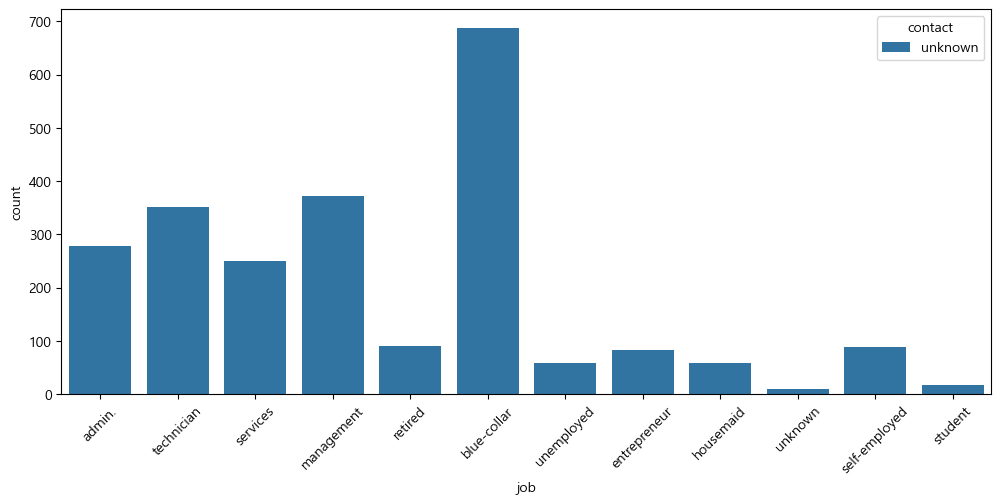

In [736]:
not_null_df = df[df['contact'] == 'unknown']

# 직업별 연락 수단 비중 시각화
plt.figure(figsize=(12, 5))
sns.countplot(data=not_null_df, x='job', hue='contact')
plt.xticks(rotation=45)
plt.show()

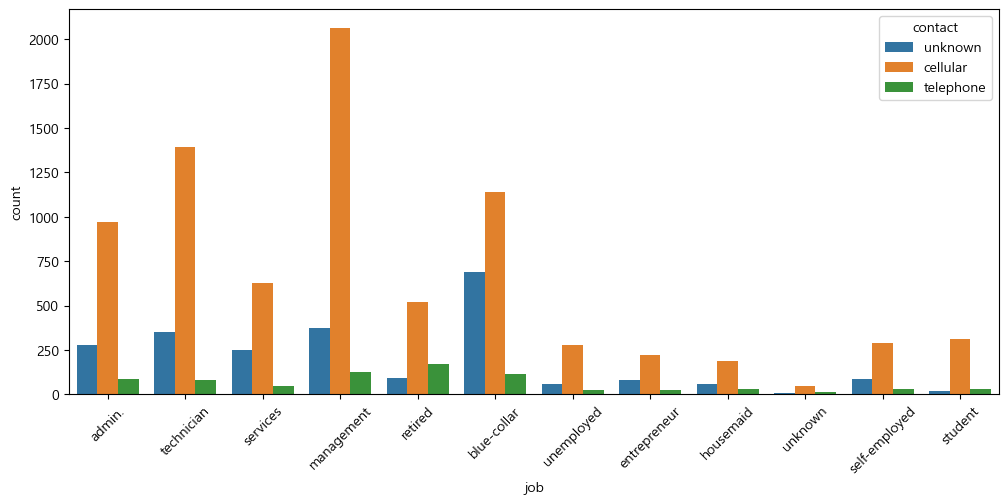

In [737]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='job', hue='contact')
plt.xticks(rotation=45)
plt.show()

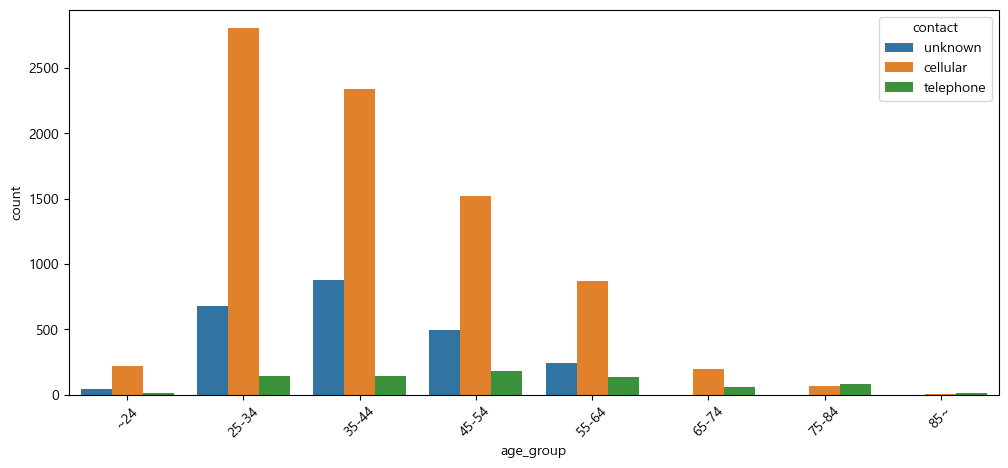

In [738]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='age_group', hue='contact')
plt.xticks(rotation=45)
plt.show()

In [739]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """ 두 범주형 변수 사이의 크래머 V 지수를 계산합니다. """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # 편향 보정(Bias correction)이 포함된 공식
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 예시: 'job'과 'contact' 사이의 연관성 확인 (결측치 제외 데이터로)
temp_df = df.drop(columns=['contact', *numeric_cols])
for col in temp_df.columns:
    score = cramers_v(temp_df[col], df['contact'])
    print(f"{col}과 Contact의 연관성 점수: {score:.4f}")

job과 Contact의 연관성 점수: 0.1809
marital과 Contact의 연관성 점수: 0.0593
education과 Contact의 연관성 점수: 0.1300
default과 Contact의 연관성 점수: 0.0438
housing과 Contact의 연관성 점수: 0.2601
loan과 Contact의 연관성 점수: 0.0183
month과 Contact의 연관성 점수: 0.4595
poutcome과 Contact의 연관성 점수: 0.2070
deposit과 Contact의 연관성 점수: 0.2566
age_group과 Contact의 연관성 점수: 0.2085


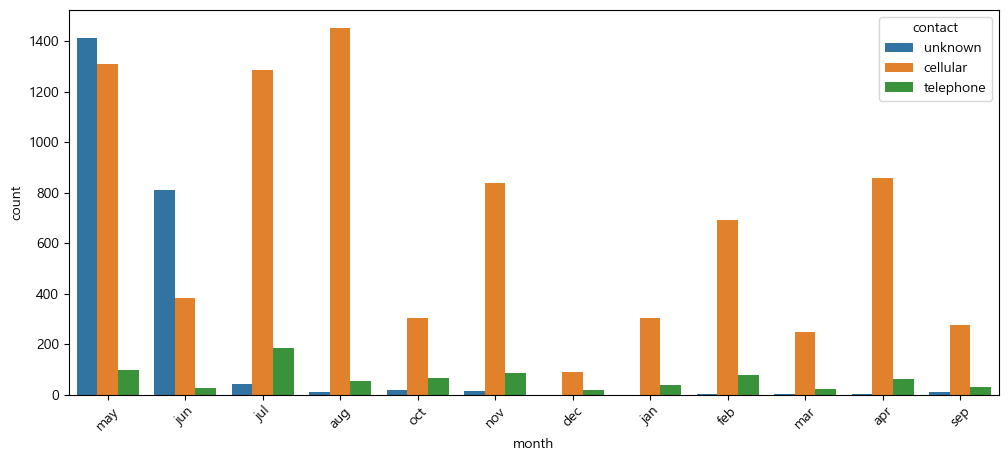

In [740]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='month', hue='contact')
plt.xticks(rotation=45)
plt.show()

### poutcome
이전 마케팅 성공여부인데 값이 성공, 실패, 기타, 알수없음 4개?

In [741]:
print("============= poutcome value_counts (before) =============")
print(df['poutcome'].value_counts())

============= poutcome value_counts (before) =============
poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64


In [742]:
temp_df = df.drop(columns=['poutcome', *numeric_cols])
for col in temp_df.columns:
    score = cramers_v(temp_df[col], df['poutcome'])
    print(f"{col}과 Poutcome의 연관성 점수: {score:.4f}")

job과 Poutcome의 연관성 점수: 0.0822
marital과 Poutcome의 연관성 점수: 0.0341
education과 Poutcome의 연관성 점수: 0.0464
default과 Poutcome의 연관성 점수: 0.0525
housing과 Poutcome의 연관성 점수: 0.1537
loan과 Poutcome의 연관성 점수: 0.0831
contact과 Poutcome의 연관성 점수: 0.2070
month과 Poutcome의 연관성 점수: 0.1849
deposit과 Poutcome의 연관성 점수: 0.2996
age_group과 Poutcome의 연관성 점수: 0.0736


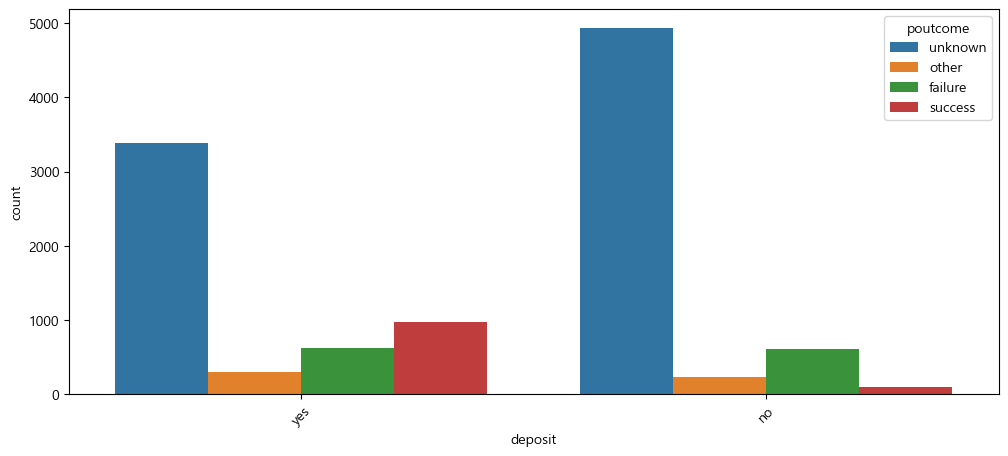

In [743]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='deposit', hue='poutcome')
plt.xticks(rotation=45)
plt.show()

### pdays
-1 (이전 연락 없음) 값 처리여부

In [744]:
df['pdays'].value_counts().sort_index()

pdays
-1      8324
 1         8
 2         8
 4         1
 5         2
        ... 
 805       1
 826       1
 828       1
 842       1
 854       1
Name: count, Length: 472, dtype: int64

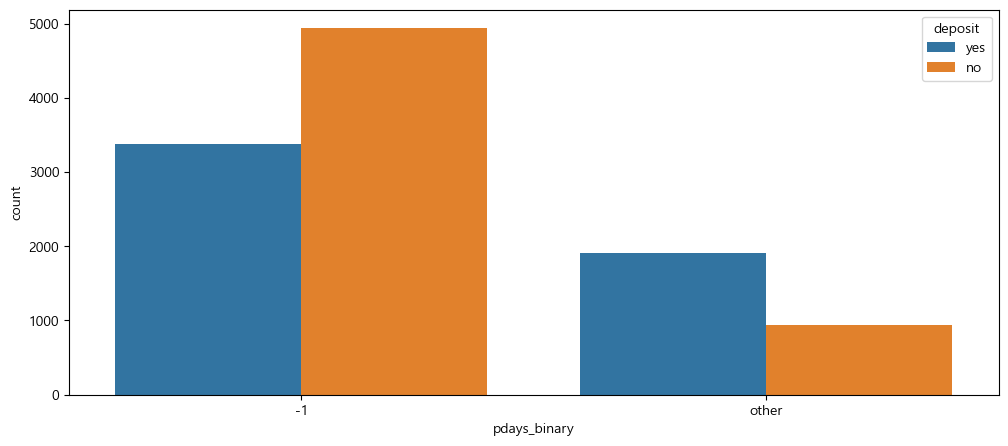

In [745]:
# -1 과 그 외의 값으로 구분하여 시각화
df['pdays_binary'] = df['pdays'].apply(lambda x: '-1' if x == -1 else 'other')
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='pdays_binary', hue='deposit')
plt.show()

In [746]:
# # pdays 그룹핑
# def pdays_grouping(x):
#     if x == -1:
#         return 0
#     elif 0 <= x <= 30:
#         return 1
#     elif 31 <= x <= 90:
#         return 2
#     elif 91 <= x <= 365:
#         return 3
#     else:
#         return 4

# df['pdays_group'] = df['pdays'].apply(pdays_grouping)
# print(df['pdays_group'].value_counts().sort_index())

In [747]:
# plt.figure(figsize=(12, 5))
# sns.countplot(data=df, x='pdays_group', hue='deposit')
# plt.show()

In [748]:
# pdays 그룹핑
def pdays_grouping(x):
    if x == -1:
        return "Never Contacted"
    elif 0 <= x <= 90:
        return "0-90 days"
    elif 91 <= x <= 180:
        return "91-180 days"
    elif 181 <= x <= 270:
        return "181-270 days"
    elif 271 <= x <= 365:
        return "271-365 days"
    else:
        return "More than 365 days"

df['pdays_group'] = df['pdays'].apply(pdays_grouping)
print(df['pdays_group'].value_counts().sort_index())

pdays_group
0-90 days              329
181-270 days           780
271-365 days           527
91-180 days            950
More than 365 days     252
Never Contacted       8324
Name: count, dtype: int64


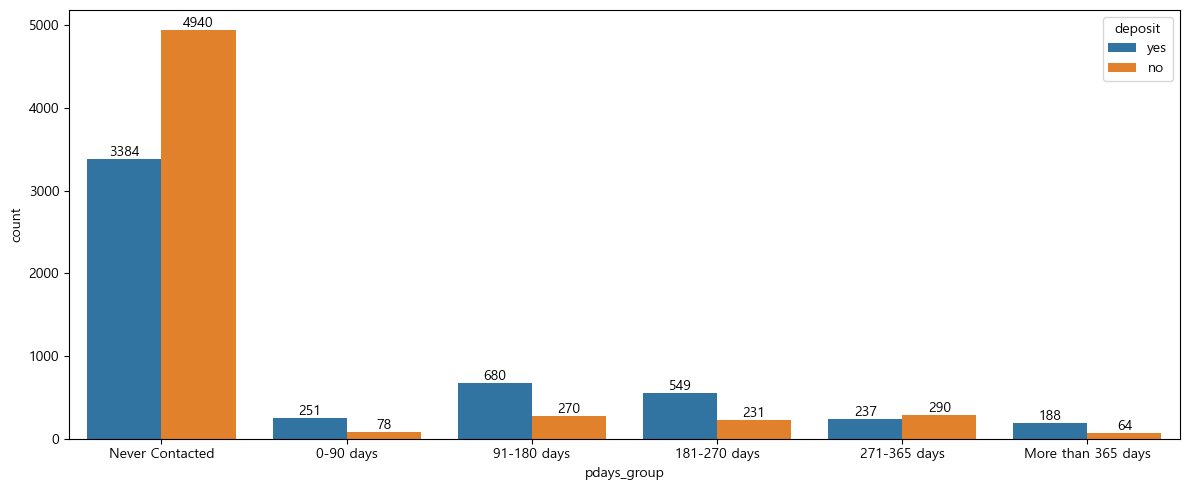

In [749]:
# pdays_group의 label 순서 지정
pdays_group_order = ["Never Contacted", "0-90 days", "91-180 days", "181-270 days", "271-365 days", "More than 365 days"]
df['pdays_group'] = pd.Categorical(df['pdays_group'], categories=pdays_group_order, ordered=True)

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='pdays_group', hue='deposit')
# 막대그래프에 값 표시
for container in plt.gca().containers:
    plt.bar_label(container)
plt.tight_layout()
plt.show()

**pdays 전처리**
- pdays 구간별 그룹핑해서 범주형 파생변수 생성

### balance
- balance 값 음수 약 700행

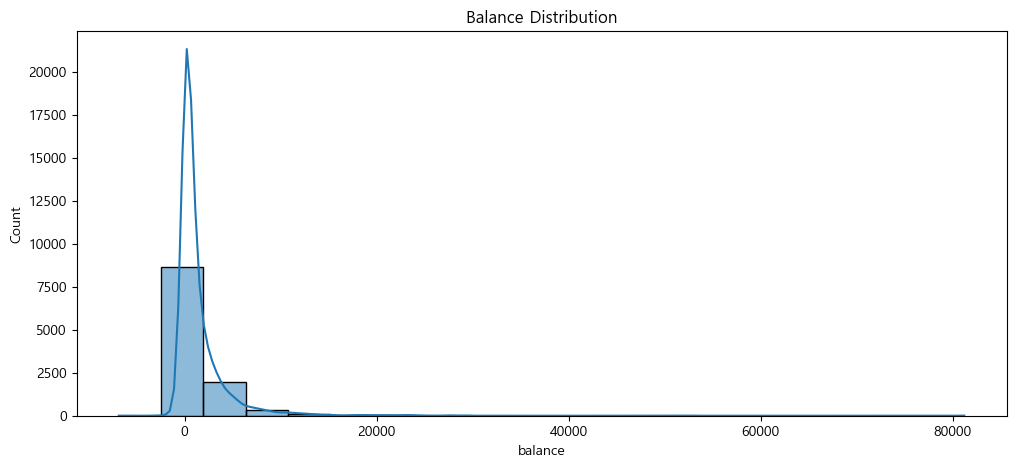

In [750]:
# balance 칼럼 분포 시각화
plt.figure(figsize=(12, 5))
sns.histplot(df['balance'], kde=True, bins=20)
plt.title("Balance Distribution")
plt.show()

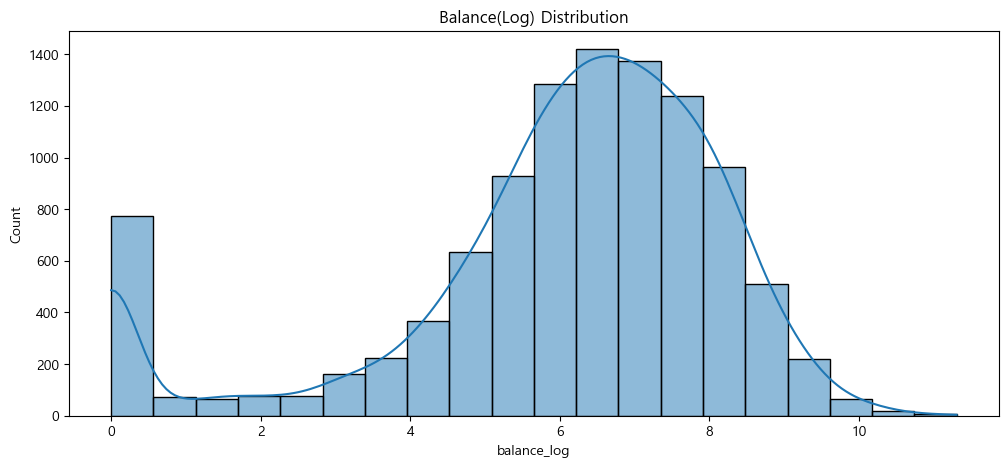

In [751]:
df['balance_log'] = np.log1p(df['balance'])

plt.figure(figsize=(12, 5))
sns.histplot(df['balance_log'], kde=True, bins=20)
plt.title("Balance(Log) Distribution")
plt.show()

In [752]:
# balance 부호에 따른 이진분류 칼럼 생성
# df['is_balance_minus'] = df['balance'].apply(lambda x: 'minus' if x < 0 else 'plus')
df['is_balance_minus'] = np.where(df['balance'] < 0, 1, 0)

# balance_plus: 양수는 그대로, 음수는 0
df['balance_plus'] = df['balance'].apply(lambda x: x if x > 0 else 0)

# balance_minus: 음수는 절대값으로, 양수는 0
df['balance_minus'] = df['balance'].apply(lambda x: abs(x) if x < 0 else 0)

# log 변환 칼럼 추가 생성
df['balance_plus_log'] = np.log1p(df['balance_plus'])
df['balance_minus_log'] = np.log1p(df['balance_minus'])
print(df.head())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day  ... deposit  age_group  pdays_binary      pdays_group  balance_log  \
0    5  ...     yes      55-64            -1  Never Contacted     7.759614   
1    5  ...     yes      55-64            -1  Never Contacted     3.828641   
2    5  ...     yes      35-44            -1  Never Contacted     7.147559   
3    5  ...     yes      55-64            -1  Never Contacted     7.814803   
4    5  ...     yes      45-54            -1  Never Contacted     5.220356   

  is_balance_minus balance_plus balance_minu

### **전처리 결과 종합**
- job : 전처리 안함
- education : unknown 값 age_group 생성 후 age_group 별 최빈값으로 대체
- contact : 전처리 안함
- poutcome : 전처리 안함
- pdays : 6개 구간화(grouping), pdays_binary 칼럼 생성
- balance : balance 칼럼을 is_balance_minus, balance_plus, balance_minus 3개 칼럼으로 분리 후 plus, minus 에 log 변환

> 모델 학습 전 pdays, balance, log_balance, balance_plus, balance_minus, day, month 칼럼 삭제 후 학습

In [753]:
print(df.info())
print(df.head())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   age                11162 non-null  int64   
 1   job                11162 non-null  object  
 2   marital            11162 non-null  object  
 3   education          11162 non-null  object  
 4   default            11162 non-null  object  
 5   balance            11162 non-null  int64   
 6   housing            11162 non-null  object  
 7   loan               11162 non-null  object  
 8   contact            11162 non-null  object  
 9   day                11162 non-null  int64   
 10  month              11162 non-null  object  
 11  duration           11162 non-null  int64   
 12  campaign           11162 non-null  int64   
 13  pdays              11162 non-null  int64   
 14  previous           11162 non-null  int64   
 15  poutcome           11162 non-null  object  
 16  depo

## EDA & 시각화

### deposit (타겟변수) 관련

- object 칼럼별

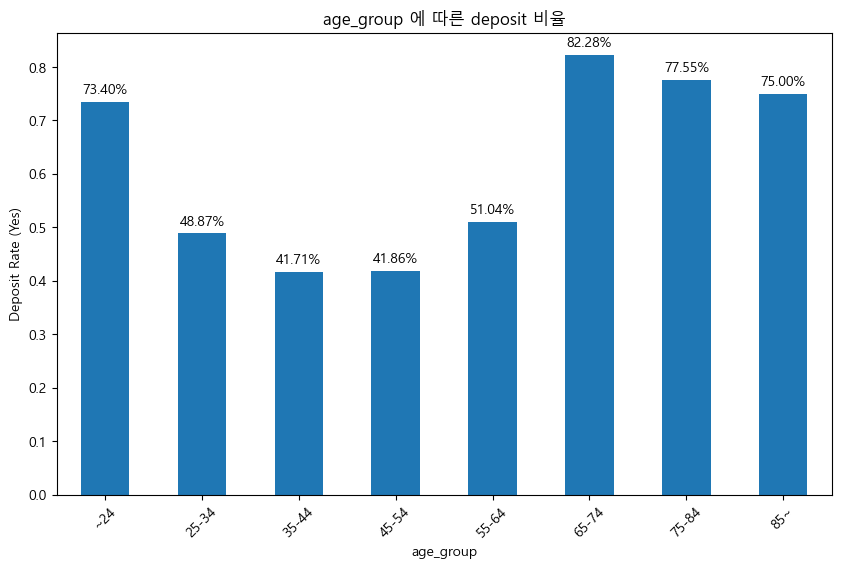

[age_group] 그룹별 deposit 가입률:
  - ~24: 73.40%
  - 25-34: 48.87%
  - 35-44: 41.71%
  - 45-54: 41.86%
  - 55-64: 51.04%
  - 65-74: 82.28%
  - 75-84: 77.55%
  - 85~: 75.00%


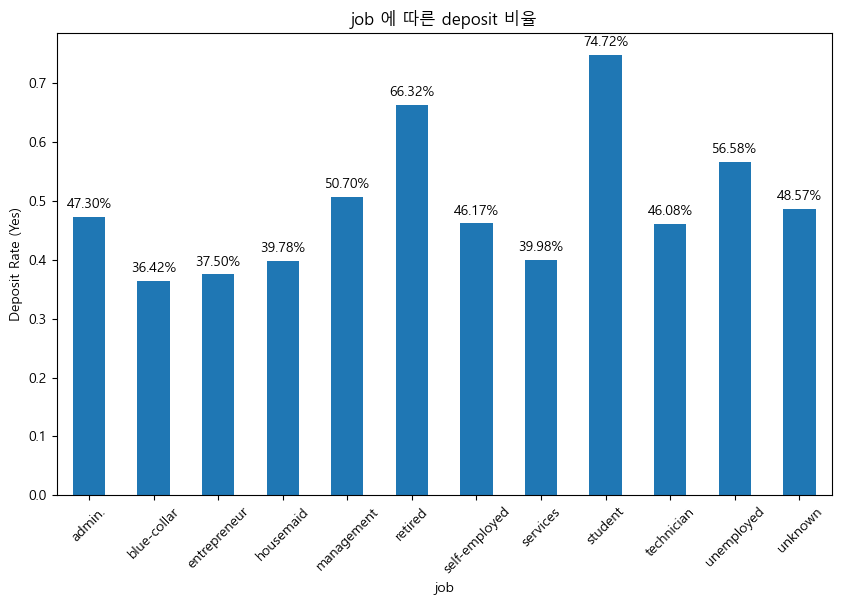

[job] 그룹별 deposit 가입률:
  - admin.: 47.30%
  - blue-collar: 36.42%
  - entrepreneur: 37.50%
  - housemaid: 39.78%
  - management: 50.70%
  - retired: 66.32%
  - self-employed: 46.17%
  - services: 39.98%
  - student: 74.72%
  - technician: 46.08%
  - unemployed: 56.58%
  - unknown: 48.57%


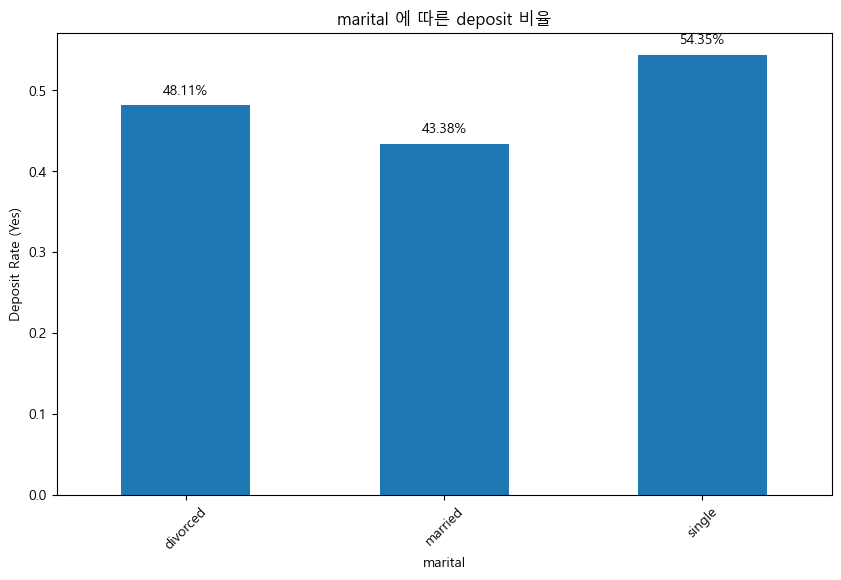

[marital] 그룹별 deposit 가입률:
  - divorced: 48.11%
  - married: 43.38%
  - single: 54.35%


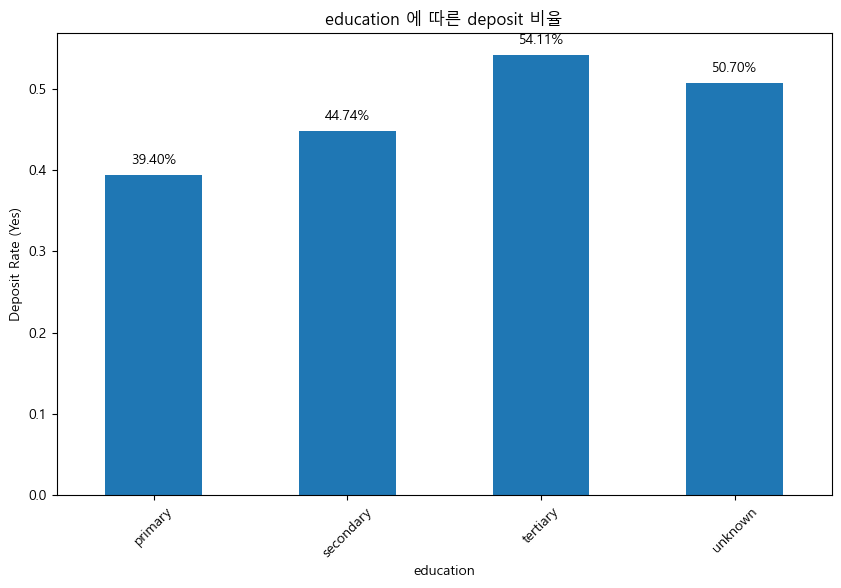

[education] 그룹별 deposit 가입률:
  - primary: 39.40%
  - secondary: 44.74%
  - tertiary: 54.11%
  - unknown: 50.70%


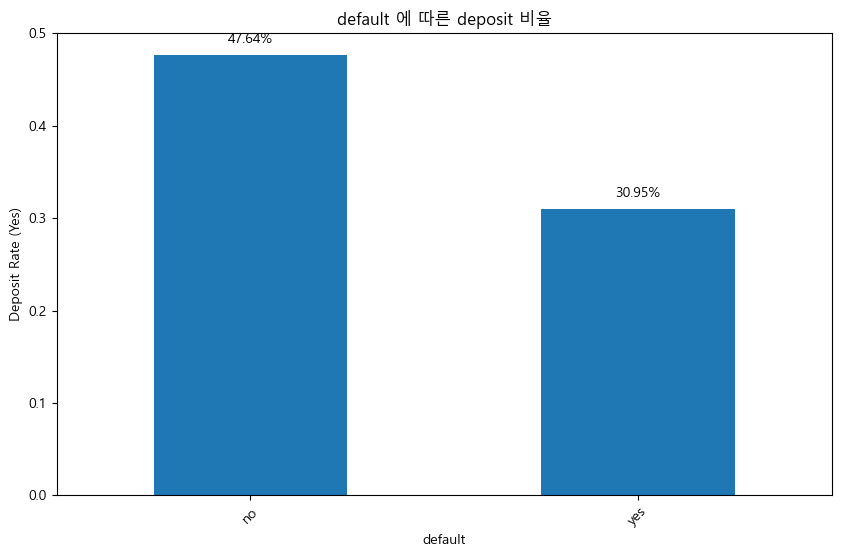

[default] 그룹별 deposit 가입률:
  - no: 47.64%
  - yes: 30.95%


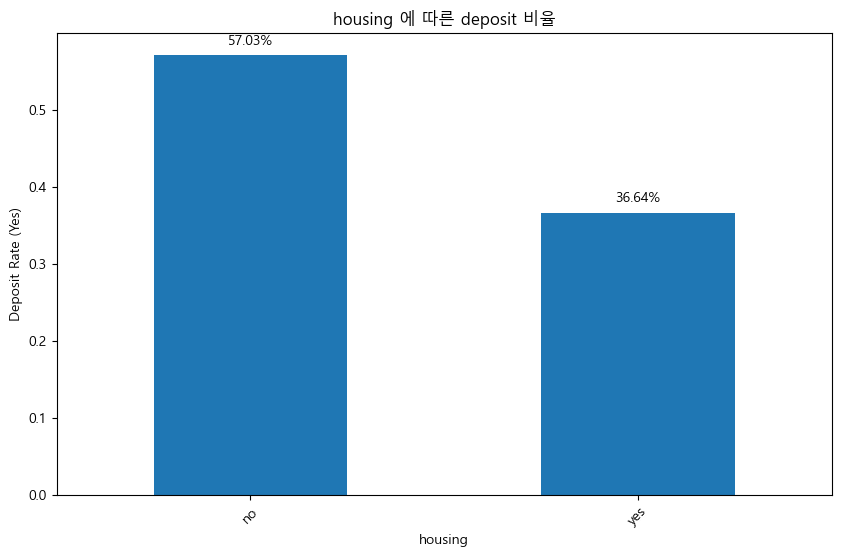

[housing] 그룹별 deposit 가입률:
  - no: 57.03%
  - yes: 36.64%


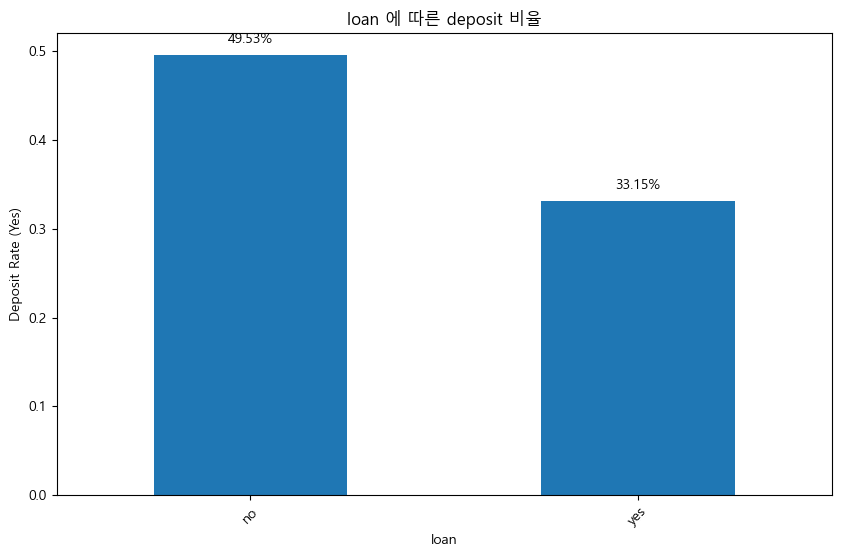

[loan] 그룹별 deposit 가입률:
  - no: 49.53%
  - yes: 33.15%


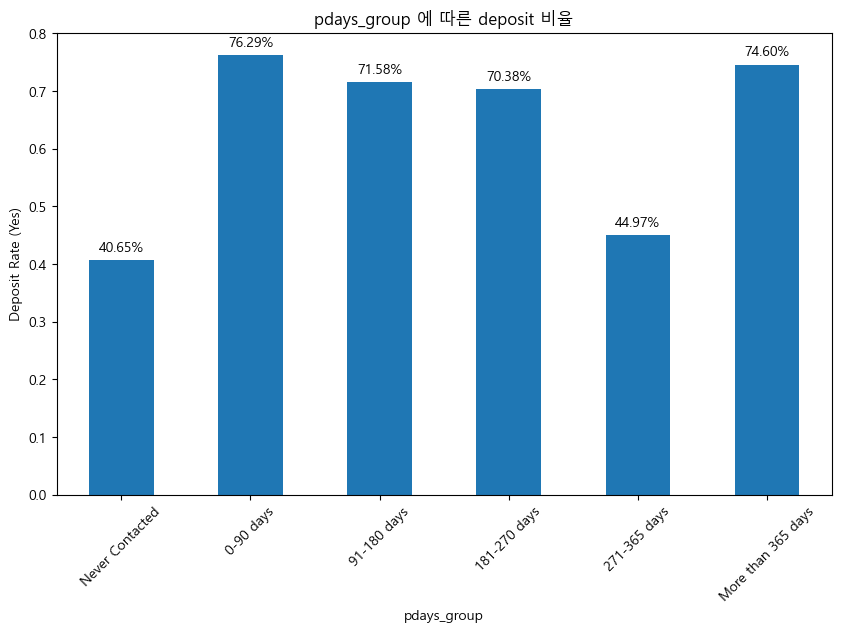

[pdays_group] 그룹별 deposit 가입률:
  - Never Contacted: 40.65%
  - 0-90 days: 76.29%
  - 91-180 days: 71.58%
  - 181-270 days: 70.38%
  - 271-365 days: 44.97%
  - More than 365 days: 74.60%


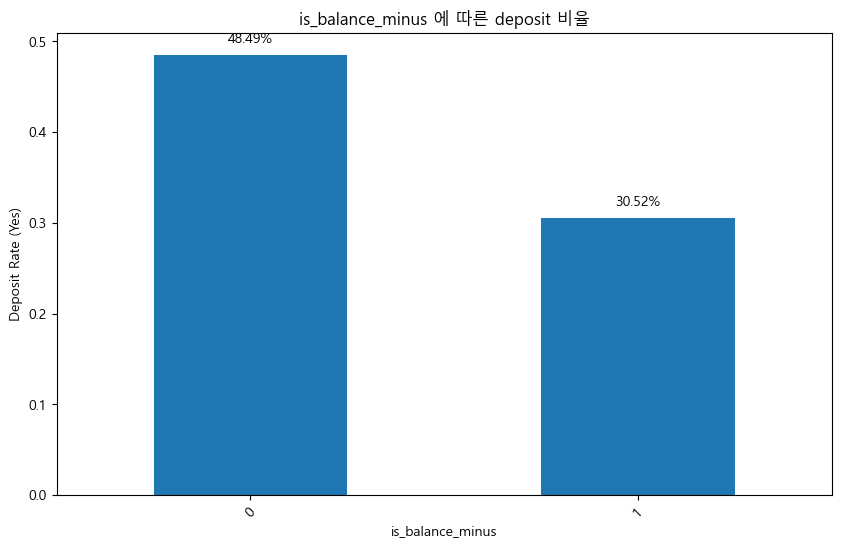

[is_balance_minus] 그룹별 deposit 가입률:
  - 0: 48.49%
  - 1: 30.52%


In [754]:
cols = ['age_group', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'pdays_group', 'is_balance_minus']

for col in cols:
    deposit_rate = df.groupby(col)['deposit'].value_counts(normalize=True).unstack()['yes']
    plt.figure(figsize=(10, 6))
    deposit_rate.plot(kind='bar')
    plt.title(f'{col} 에 따른 deposit 비율')
    for i, v in enumerate(deposit_rate):
        plt.text(i, v + 0.01, f"{v:.2%}", ha='center', va='bottom')
    plt.ylabel('Deposit Rate (Yes)')
    plt.xticks(rotation=45)
    plt.show()

    # 시각화 결과 텍스트로 정리
    print(f"[{col}] 그룹별 deposit 가입률:")
    for group, rate in deposit_rate.items():
        print(f"  - {group}: {rate:.2%}")

> pdays_group 271-365 에서만 deposit ratio가 낮은 이유 : 은행 캠페인이 1년단위 정기예금으로, deposit이 만기해지되는 구간으로 추정

- numeric 칼럼별

In [755]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous,balance_log,is_balance_minus,balance_plus,balance_minus,balance_plus_log,balance_minus_log
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,1.048300e+04,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557,-inf,0.061638,1548.497223,19.958699,5.617849,0.317506
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007,NaN,0.240507,3213.199942,129.690924,2.657302,1.282128
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000,-inf,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000,5.214936e+00,0.000000,122.000000,0.000000,4.812184,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000,6.437752e+00,0.000000,550.000000,0.000000,6.311735,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000,7.517793e+00,0.000000,1708.000000,0.000000,7.443664,0.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000,1.130473e+01,1.000000,81204.000000,6847.000000,11.304732,8.831712


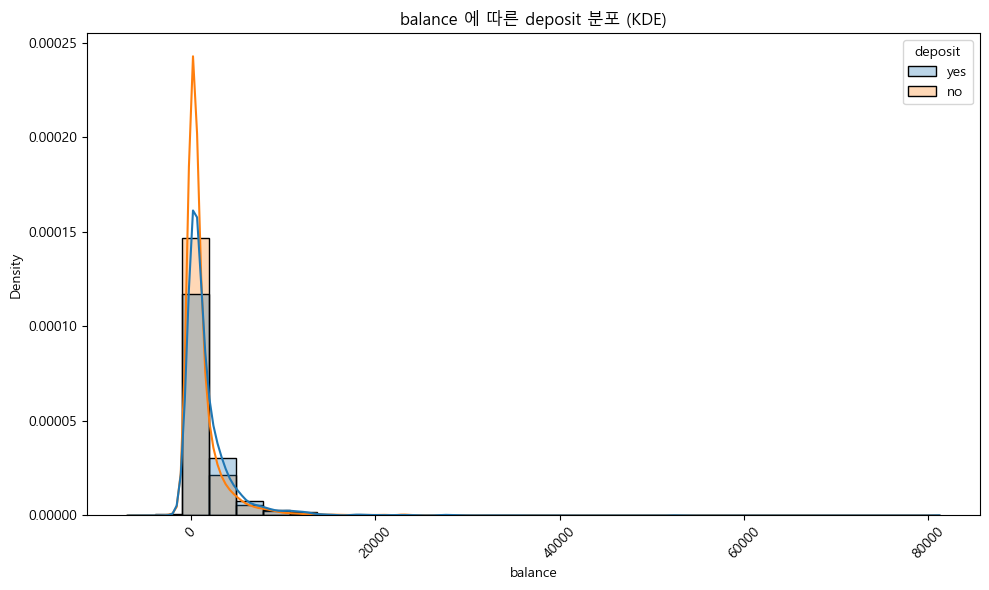

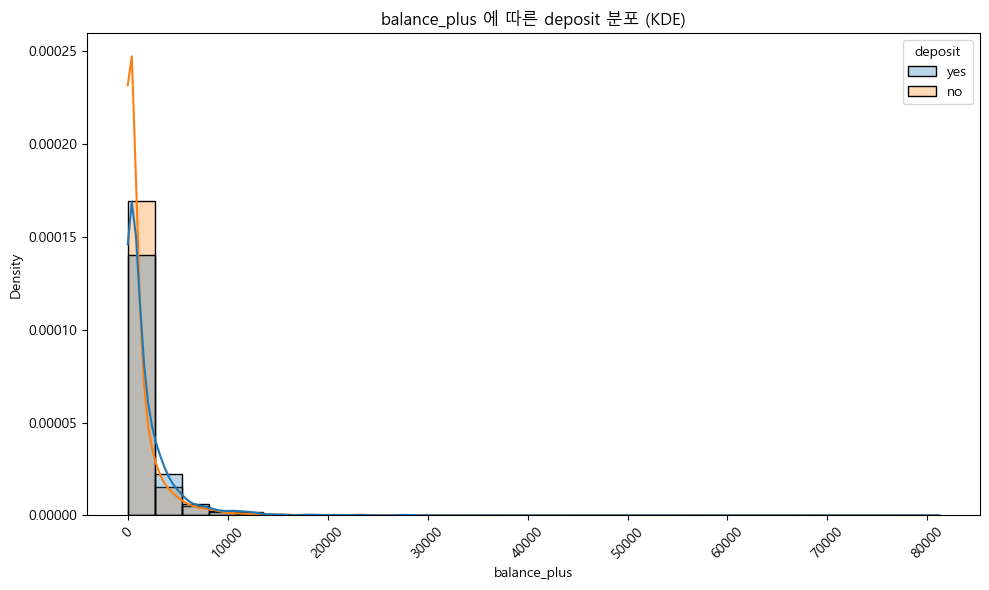

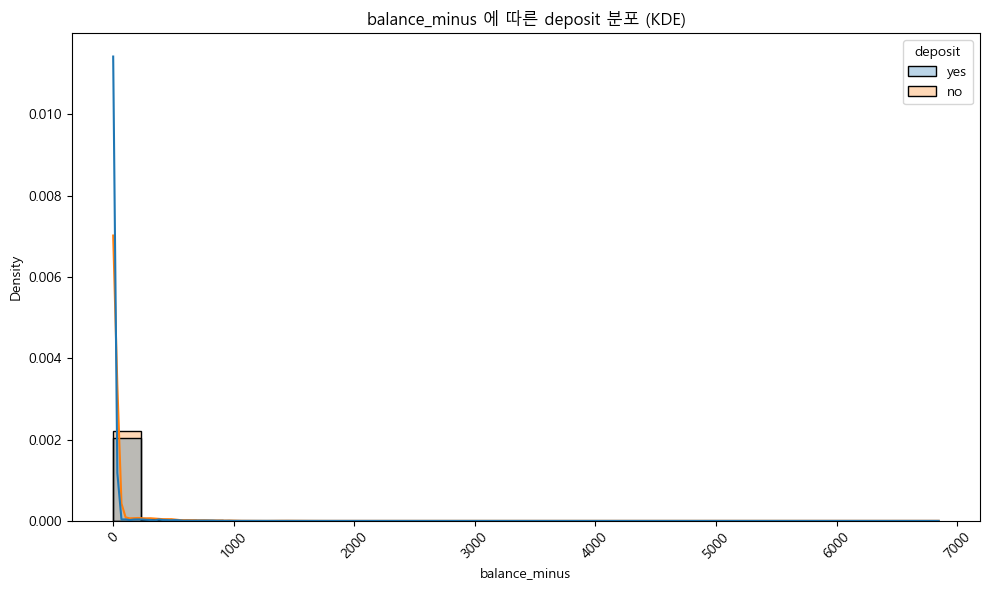

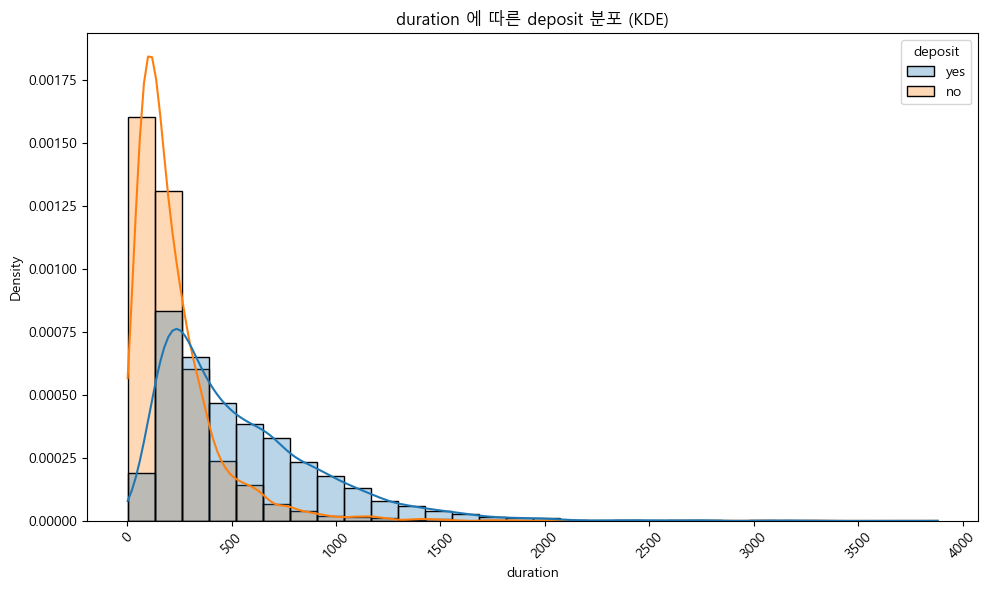

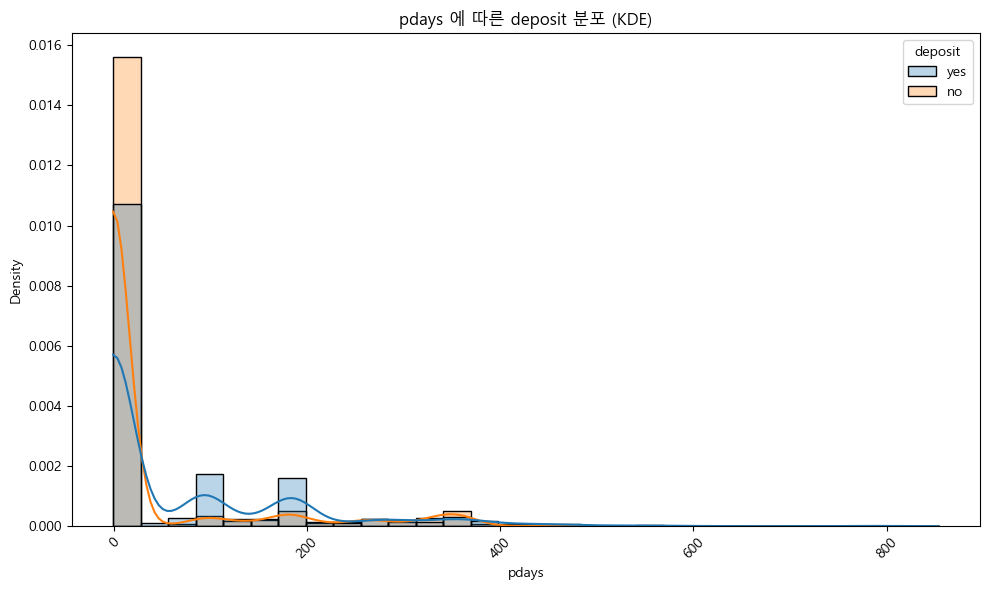

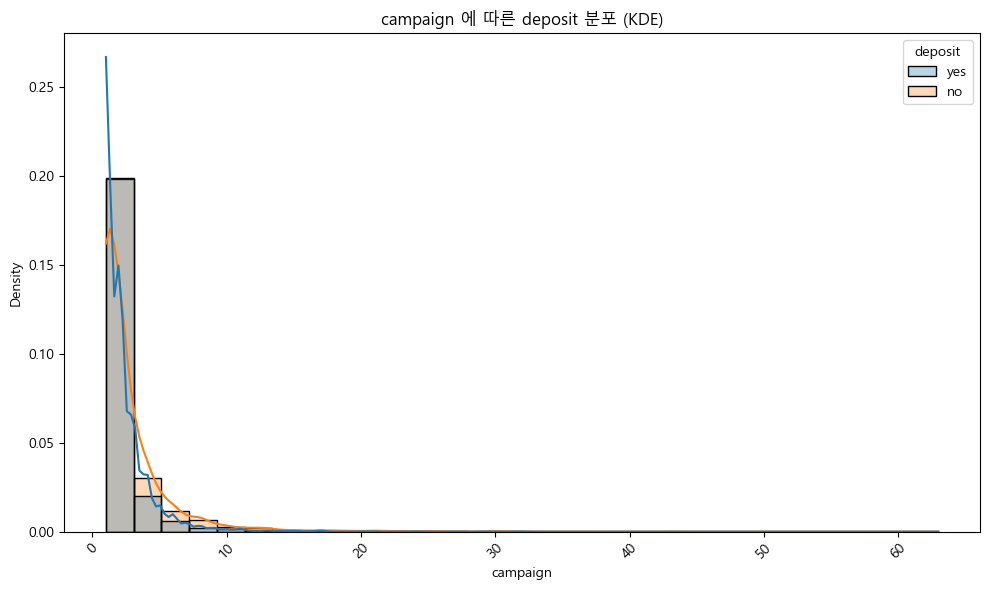

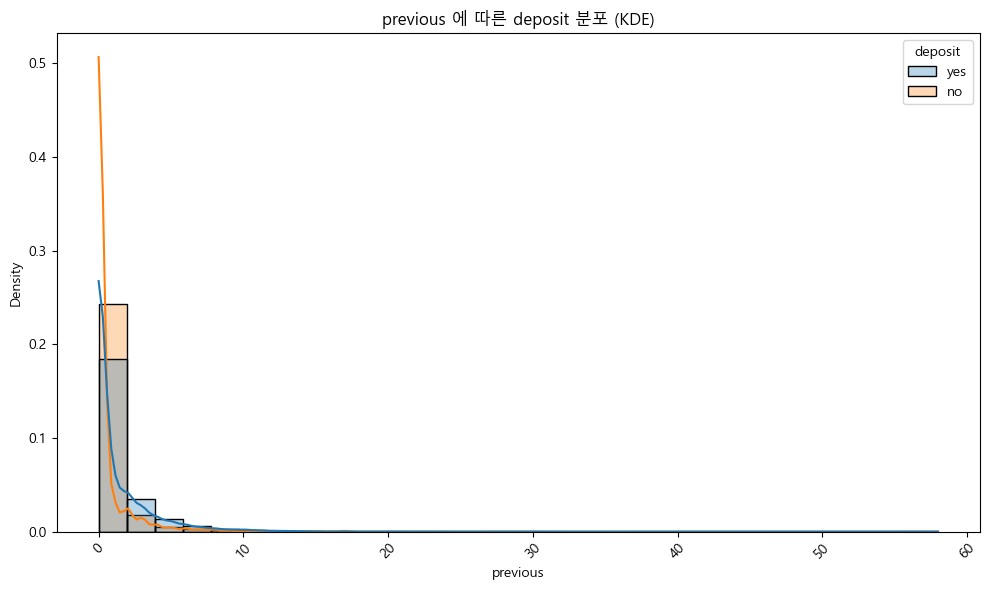

In [756]:
num_cols = ['balance', 'balance_plus', 'balance_minus', 'duration', 'pdays', 'campaign', 'previous']

for col in num_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df,
        x=col,
        hue='deposit',
        kde=True,
        stat='density',  # KDE와 스케일 맞추려면 density 권장
        bins=30,
        alpha=0.3,        # 히스토그램 투명하게
    )
    plt.title(f'{col} 에 따른 deposit 분포 (KDE)')
    plt.ylabel('Density')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

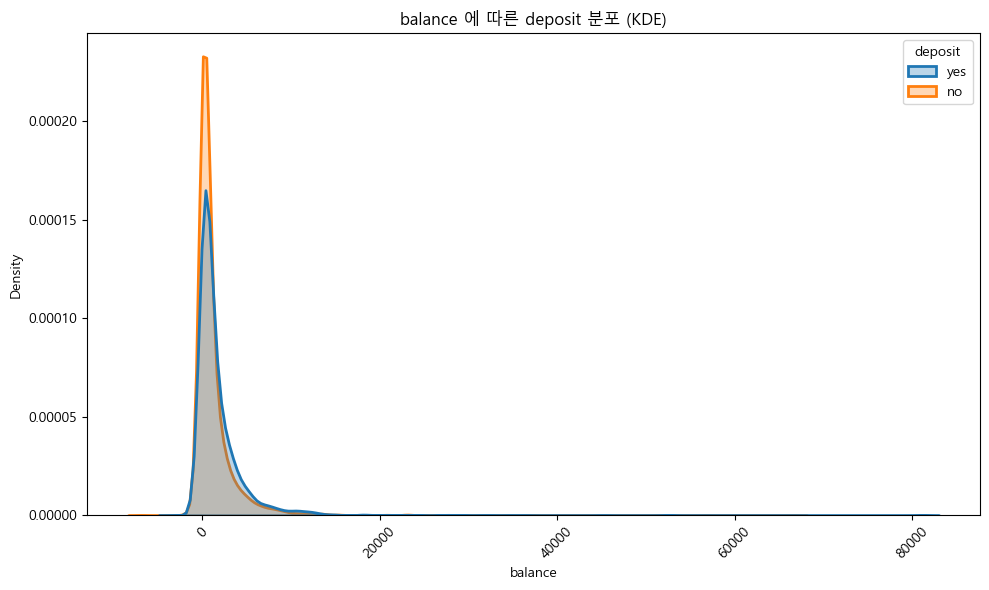

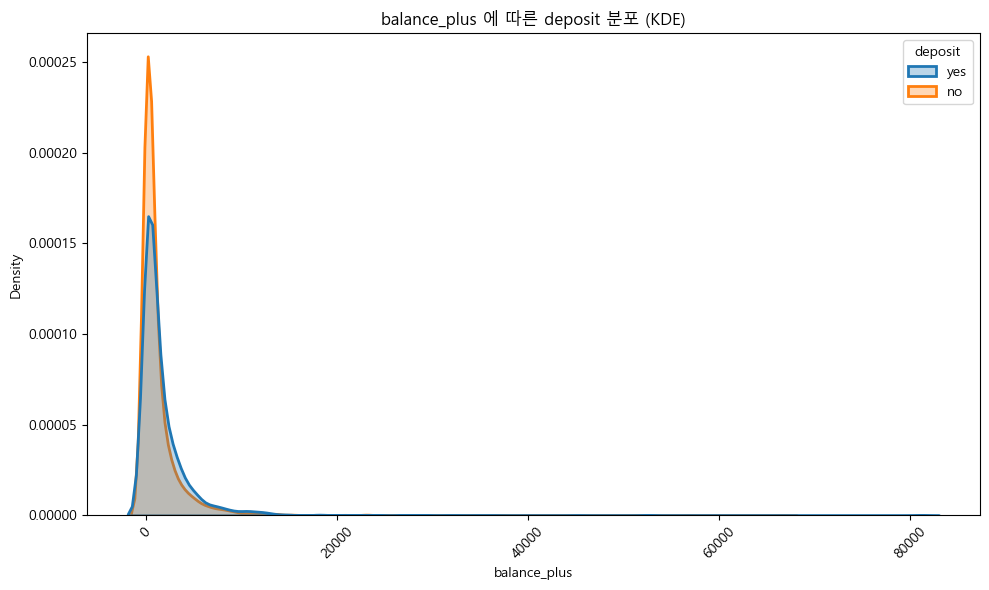

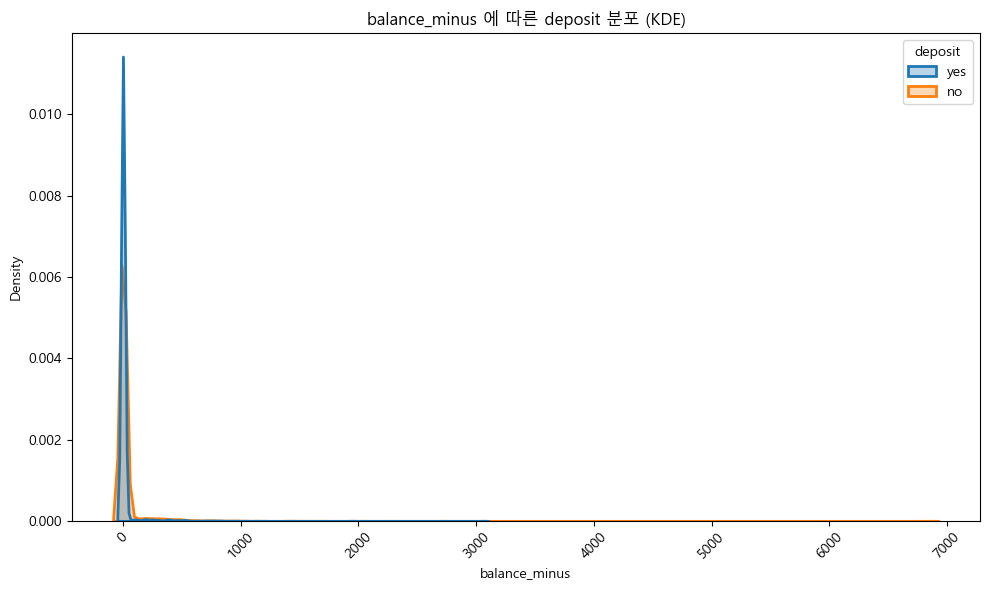

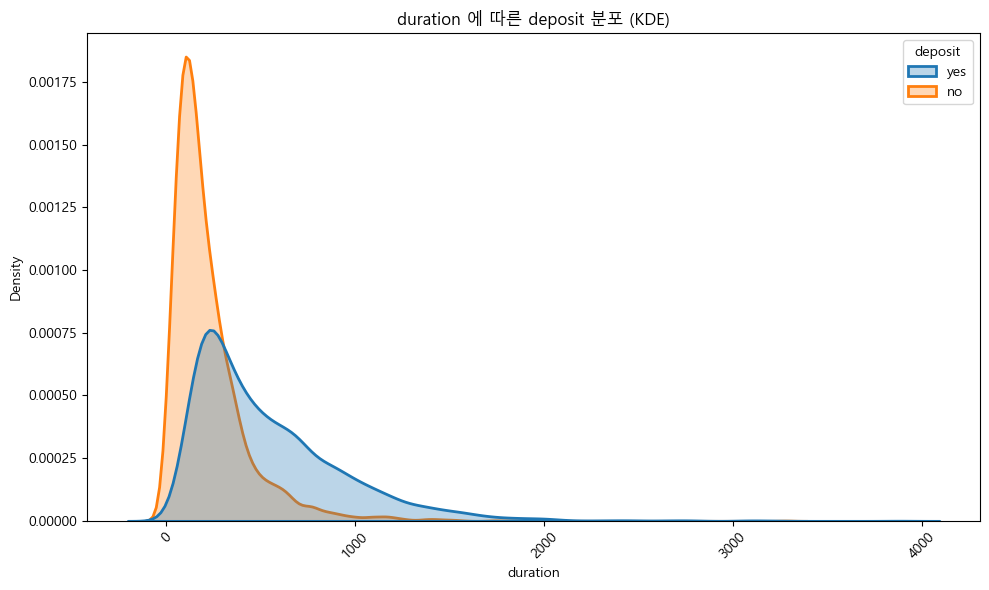

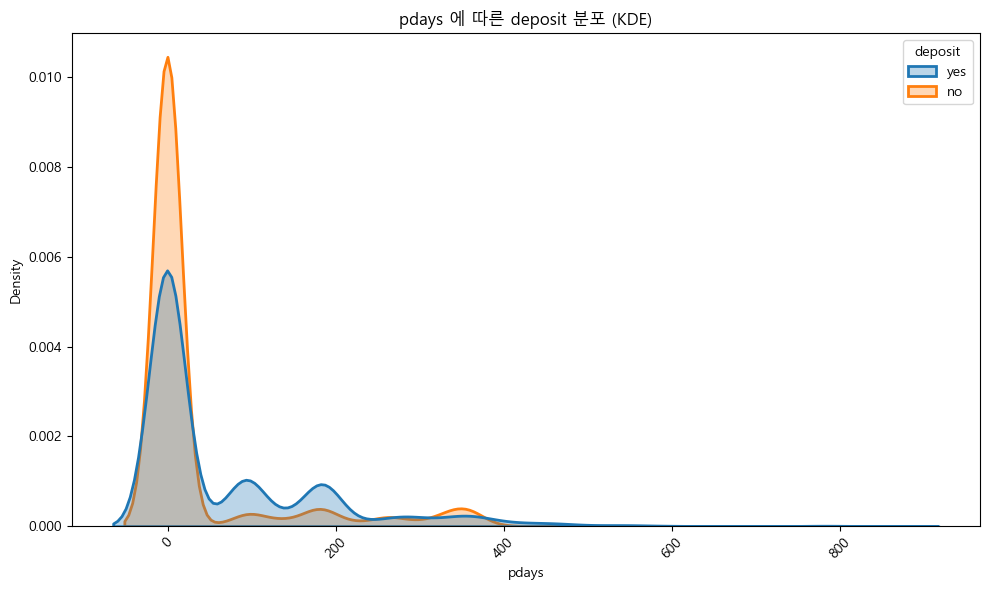

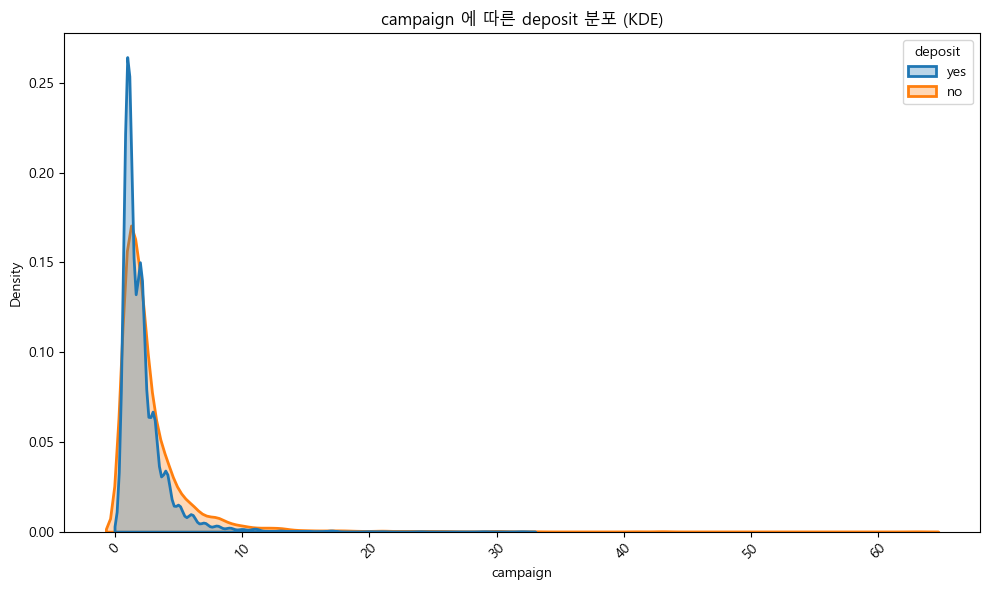

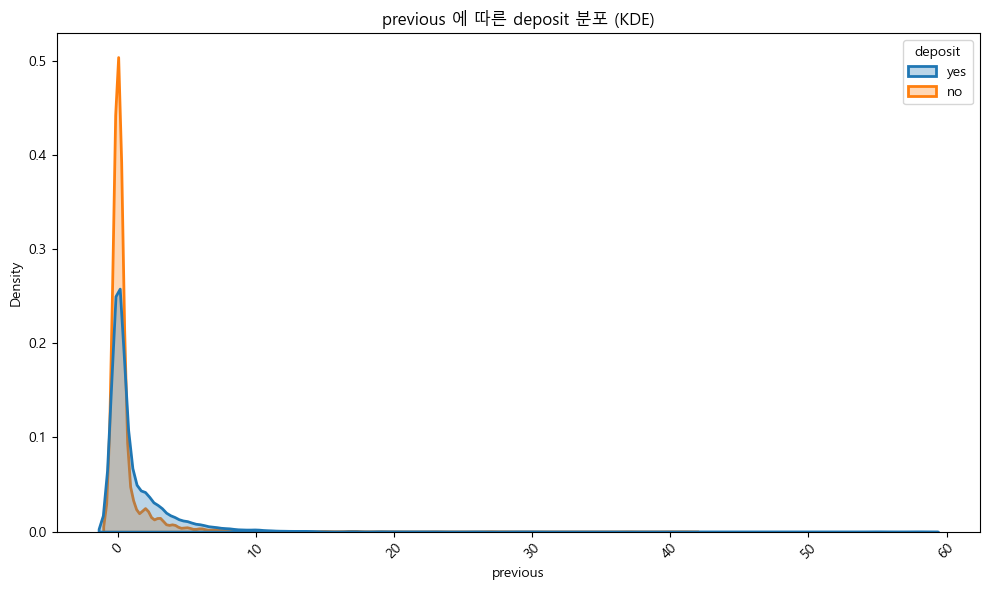

In [757]:
for col in num_cols:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        data=df,
        x=col,
        hue='deposit',
        fill=True,        # 라인 아래 영역 채우기
        alpha=0.3,
        linewidth=2,
    )
    plt.title(f'{col} 에 따른 deposit 분포 (KDE)')
    plt.ylabel('Density')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 시계열 칼럼 시각화

#### month

- month * campaign

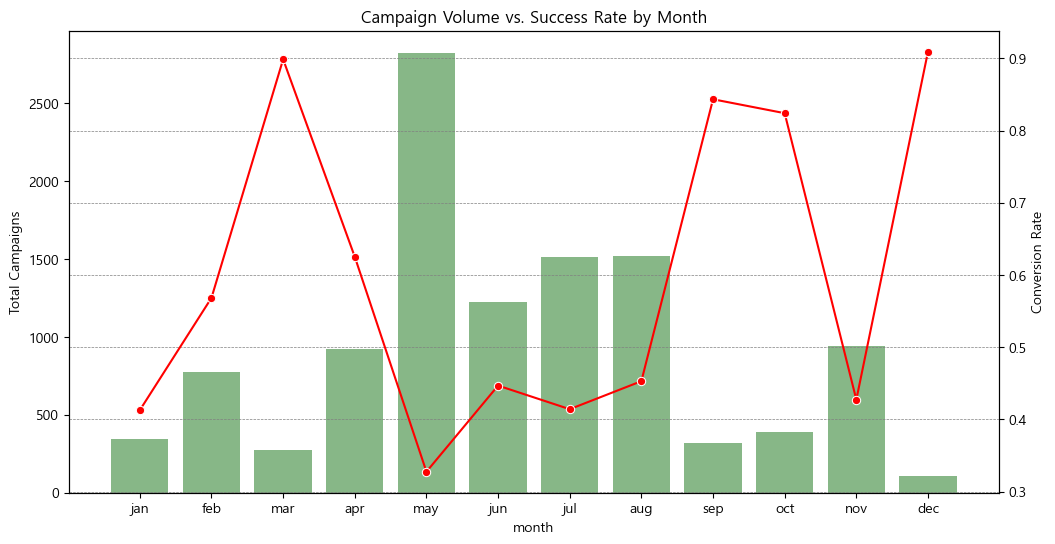

In [758]:
df['deposit_bool'] = (df['deposit'] == 'yes').astype(int)
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# 월별 통계 계산
monthly_stats = df.groupby('month')['deposit_bool'].agg(['count', 'mean']).reindex(month_order)

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. 캠페인 횟수 (막대)
sns.barplot(x=monthly_stats.index, y=monthly_stats['count'], color='green', ax=ax1, alpha=0.5)
ax1.set_ylabel('Total Campaigns')

# 2. 가입률 (추세선)
ax2 = ax1.twinx()
sns.lineplot(x=monthly_stats.index, y=monthly_stats['mean'], marker='o', color='red', ax=ax2)
ax2.set_ylabel('Conversion Rate')

plt.title('Campaign Volume vs. Success Rate by Month')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

현재 캠페인 기준 접촉 횟수가 낮은 구간에서는 deposit 과 비례, 일정 횟수 이상 구간에서는 deposit 과 반비례로 전환
> campaign EDA 시 추가 진행

- month * balance

#### day

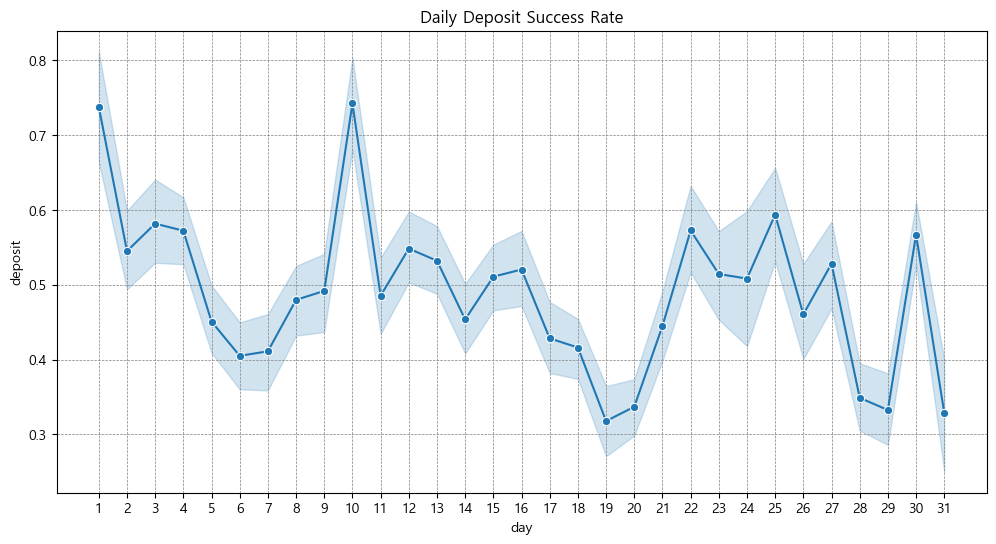

In [759]:
# 일별 가입률
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='day', y=(df['deposit'] == 'yes'), marker='o', estimator=np.mean)
plt.title('Daily Deposit Success Rate')
plt.xticks(ticks=range(1, 32), labels=[str(i) for i in range(1, 32)])
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

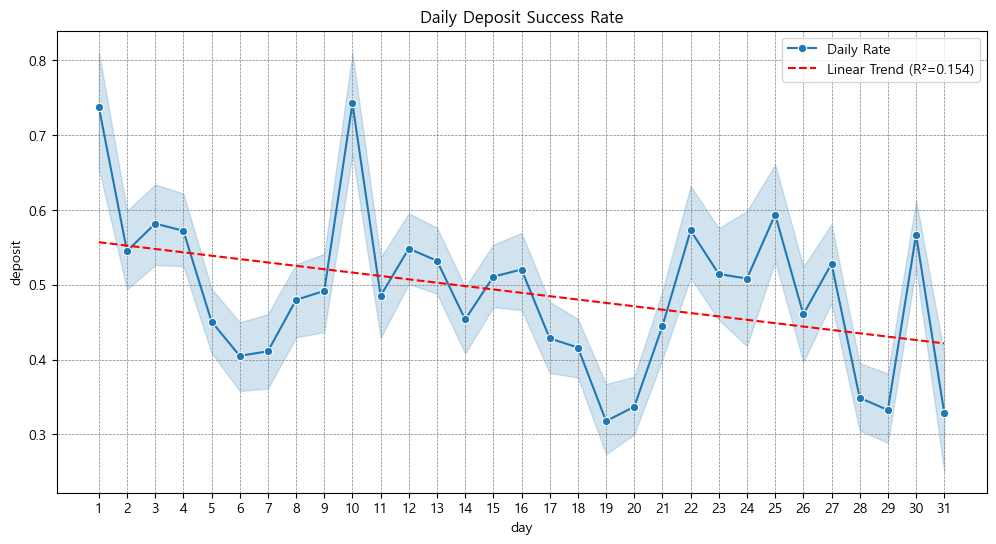

In [760]:
# 일별 가입률 계산
daily_rate = df.groupby('day')['deposit'].apply(lambda x: (x == 'yes').mean())
days = daily_rate.index.values
rates = daily_rate.values

# 선형 회귀 추세선 계산
slope, intercept, r_value, p_value, std_err = stats.linregress(days, rates)
trend_line = slope * days + intercept

# 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='day', y=(df['deposit'] == 'yes'), marker='o', estimator=np.mean, label='Daily Rate')

# 추세선 추가
plt.plot(days, trend_line, color='red', linestyle='--', linewidth=1.5,
         label=f'Linear Trend (R²={r_value**2:.3f})')

plt.title('Daily Deposit Success Rate')
plt.xticks(ticks=range(1, 32), labels=[str(i) for i in range(1, 32)])
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

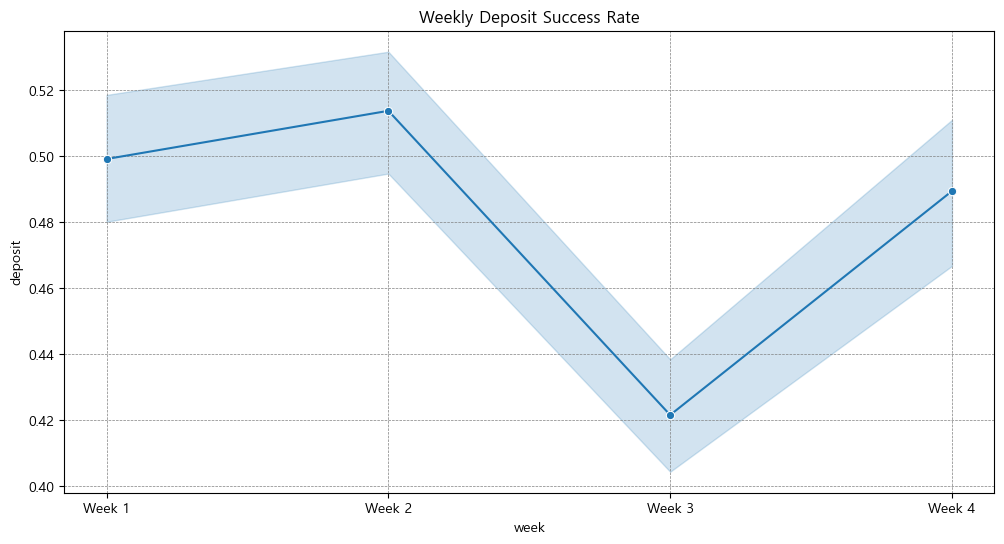

In [761]:
# 주단위 가입률
for i in range(1, 32):
    if i <= 7:
        df.loc[df['day'] == i, 'week'] = 'Week 1'
    elif 8 <= i <= 14:
        df.loc[df['day'] == i, 'week'] = 'Week 2'
    elif 15 <= i <= 21:
        df.loc[df['day'] == i, 'week'] = 'Week 3'
    elif 22 <= i <= 28:
        df.loc[df['day'] == i, 'week'] = 'Week 4'
    else:
        'Week 5'

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='week', y=(df['deposit'] == 'yes'), marker='o', estimator=np.mean)
plt.title('Weekly Deposit Success Rate')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

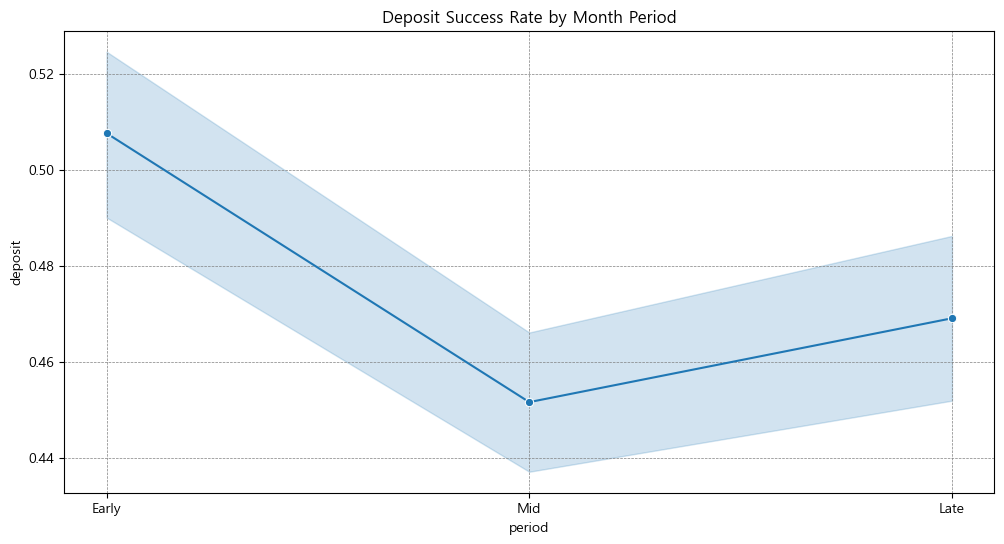

In [762]:
# 월초 ~ 월말 가입률
for i in range(1, 32):
    if i <= 10:
        df.loc[df['day'] == i, 'period'] = 'Early'
    elif 11 <= i <= 20:
        df.loc[df['day'] == i, 'period'] = 'Mid'
    else:
        df.loc[df['day'] == i, 'period'] = 'Late'
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='period', y=(df['deposit'] == 'yes'), marker='o', estimator=np.mean)
plt.title('Deposit Success Rate by Month Period')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

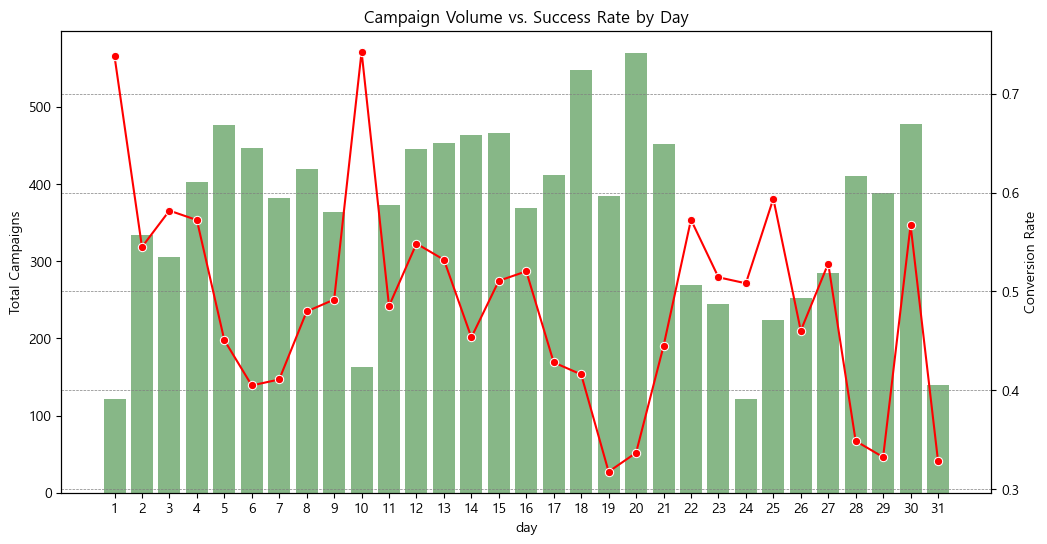

In [763]:
# 일별 통계 계산
daily_stats = df.groupby('day')['deposit_bool'].agg(['count', 'mean'])

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. 캠페인 횟수 (막대)
sns.barplot(x=daily_stats.index, y=daily_stats['count'], color='green', ax=ax1, alpha=0.5)
ax1.set_ylabel('Total Campaigns')

# 2. 가입률 (추세선)
ax2 = ax1.twinx()
sns.lineplot(x=daily_stats.index.astype(str), y=daily_stats['mean'], marker='o', color='red', ax=ax2)
ax2.set_ylabel('Conversion Rate')

plt.title('Campaign Volume vs. Success Rate by Day')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

#### date * deposit

In [764]:
# # 주단위 deposit 트렌드 시각화
# df['week'] = df['date'].dt.isocalendar().week
# weekly_trend = df.groupby('week')['deposit'].value_counts(normalize=True).unstack()

# plt.figure(figsize=(15, 6))
# sns.lineplot(data=weekly_trend, markers=True)

# weeks = weekly_trend.index
# plt.xticks(ticks=weeks, labels=[f"W{int(i)}" for i in weeks], rotation=45)

# plt.title("Weekly Deposit Trend", fontsize=14)
# plt.grid(axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

In [765]:
# weekly_customer_trend = df.groupby(['week', 'pdays_binary'])['deposit'].value_counts(normalize=True).unstack()

# df['week'] = df['date'].dt.isocalendar().week

# # 3. 주차별 & 고객유형별 deposit='yes' 비율 계산
# # normalize=True를 사용해 각 그룹 내에서의 비율을 구합니다.
# weekly_res = df.groupby(['week', 'pdays_binary'])['deposit'].value_counts(normalize=True).unstack()

# # 'yes' 컬럼만 추출 (가입 성공률)
# trend_data = weekly_res['yes'].reset_index()

# # 4. 시각화
# plt.figure(figsize=(14, 6))

# # 신규/기존 고객별로 선 그래프 그리기
# sns.lineplot(data=trend_data, x='week', y='yes', hue='pdays_binary', 
#              marker='o', linewidth=2, palette='viridis')

# # 그래프 스타일링
# plt.title("Weekly Deposit Rate: New vs Previous Customers", fontsize=15, pad=20)
# plt.xlabel("Week of Year", fontsize=12)
# plt.ylabel("Deposit Rate (Yes %)", fontsize=12)
# plt.legend(title='pdays_binary', frameon=True)

# # x축 눈금 최적화 (데이터가 있는 주차만 표시)
# weeks = sorted(trend_data['week'].unique())
# plt.xticks(ticks=weeks, labels=[f"W{int(i)}" for i in weeks], rotation=45)

# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

#### date * pdays * deposit

In [766]:
# # pdays_group별 deposit 트렌드 시각화
# weekly_res = df.groupby(['week', 'pdays_group'])['deposit'].value_counts(normalize=True).unstack()
# trend_data = weekly_res['yes'].reset_index()
# plt.figure(figsize=(14, 6))
# sns.lineplot(data=trend_data, x='week', y='yes', hue='pdays_group', 
#              marker='o', linewidth=2, palette='viridis')
# plt.title("Weekly Deposit Rate by pdays_group", fontsize=15, pad=20)
# plt.xlabel("Week of Year", fontsize=12)
# plt.ylabel("Deposit Rate (Yes %)", fontsize=12)
# plt.legend(title='pdays_group', frameon=True)
# weeks = sorted(trend_data['week'].unique())
# plt.xticks(ticks=weeks, labels=[f"W{int(i)}" for i in weeks], rotation=45)
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

In [767]:
# # 1. 시각화에 사용된 trend_data를 피벗 테이블로 변환 (행: 주차, 열: 그룹)
# trend_table = trend_data.pivot(index='week', columns='pdays_group', values='yes')

# # 2. 가독성을 위해 소수점 둘째자리까지 퍼센트(%)로 변환 (옵션)
# trend_table_pct = (trend_table * 100).round(2)

# # 3. 전체 출력 (주차가 많으므로 상위/하위 일부만 보거나 전체 출력 설정)
# print("주차별 pdays_group 가입률 (단위: %)")
# print(trend_table_pct)

# # # 4. 특정 주차만 뽑아서 요약하고 싶다면
# # print("\n가입률이 가장 높은 TOP 5 주차 (그룹별)")
# # for col in trend_table_pct.columns:
# #     top_week = trend_table_pct[col].idxmax()
# #     top_val = trend_table_pct[col].max()
# #     print(f"[{col}] 그룹: W{top_week}에 {top_val}%로 최고치 기록")

### 인구통계 관련

#### age

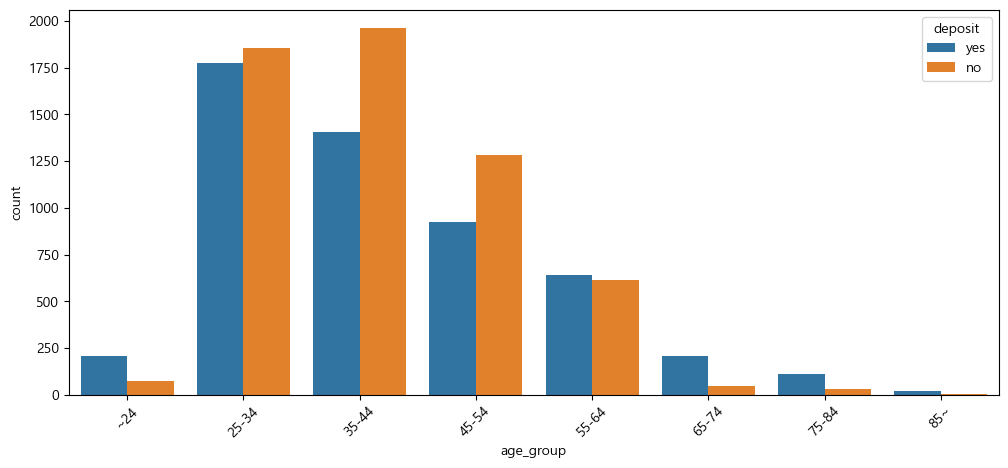

In [768]:
# job, age_group 별 deposit 비율 시각화
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='age_group', hue='deposit')
plt.xticks(rotation=45)
plt.show()

#### Job

- age

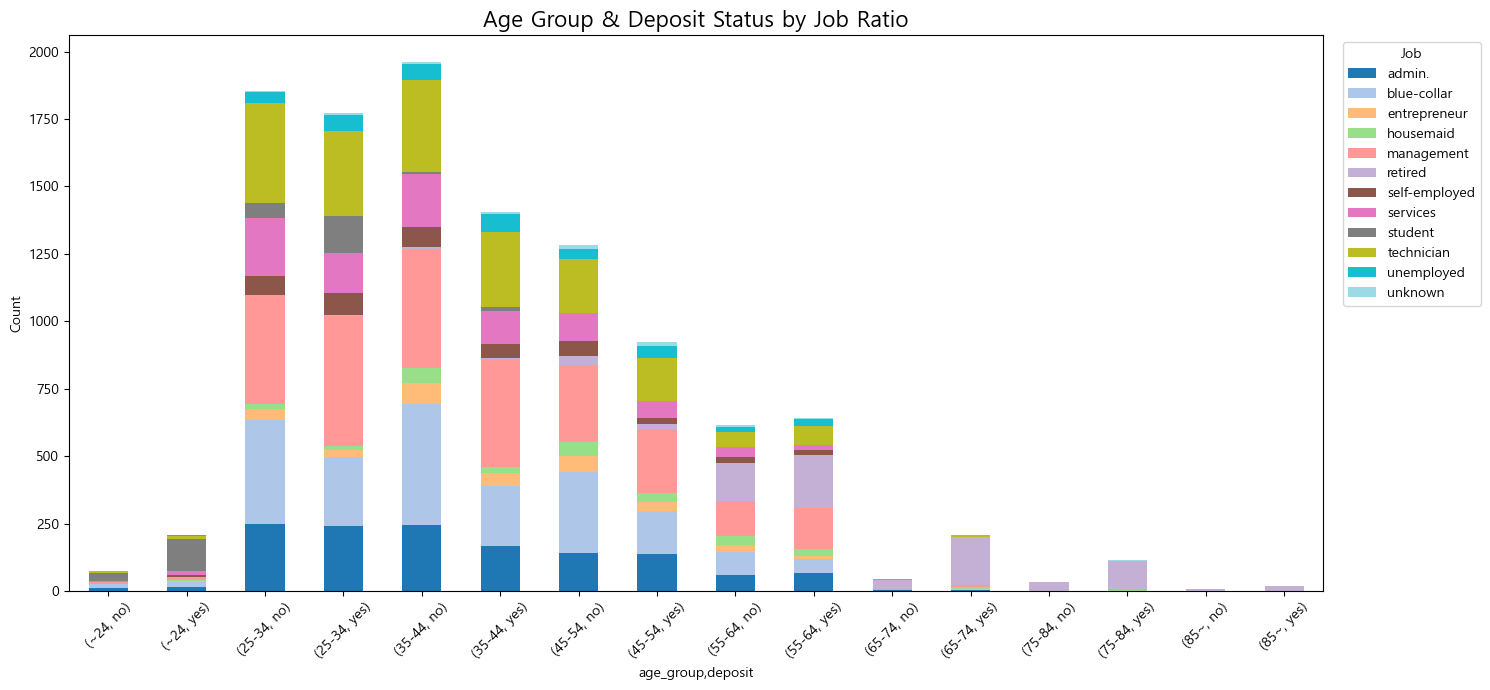

In [769]:
# 연령대와 예금 여부별로 직업군을 집계
stacked_data = df.groupby(['age_group', 'deposit', 'job']).size().unstack(fill_value=0)

# 시각화
stacked_data.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='tab20')

plt.title("Age Group & Deposit Status by Job Ratio", fontsize=16)
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title='Job', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

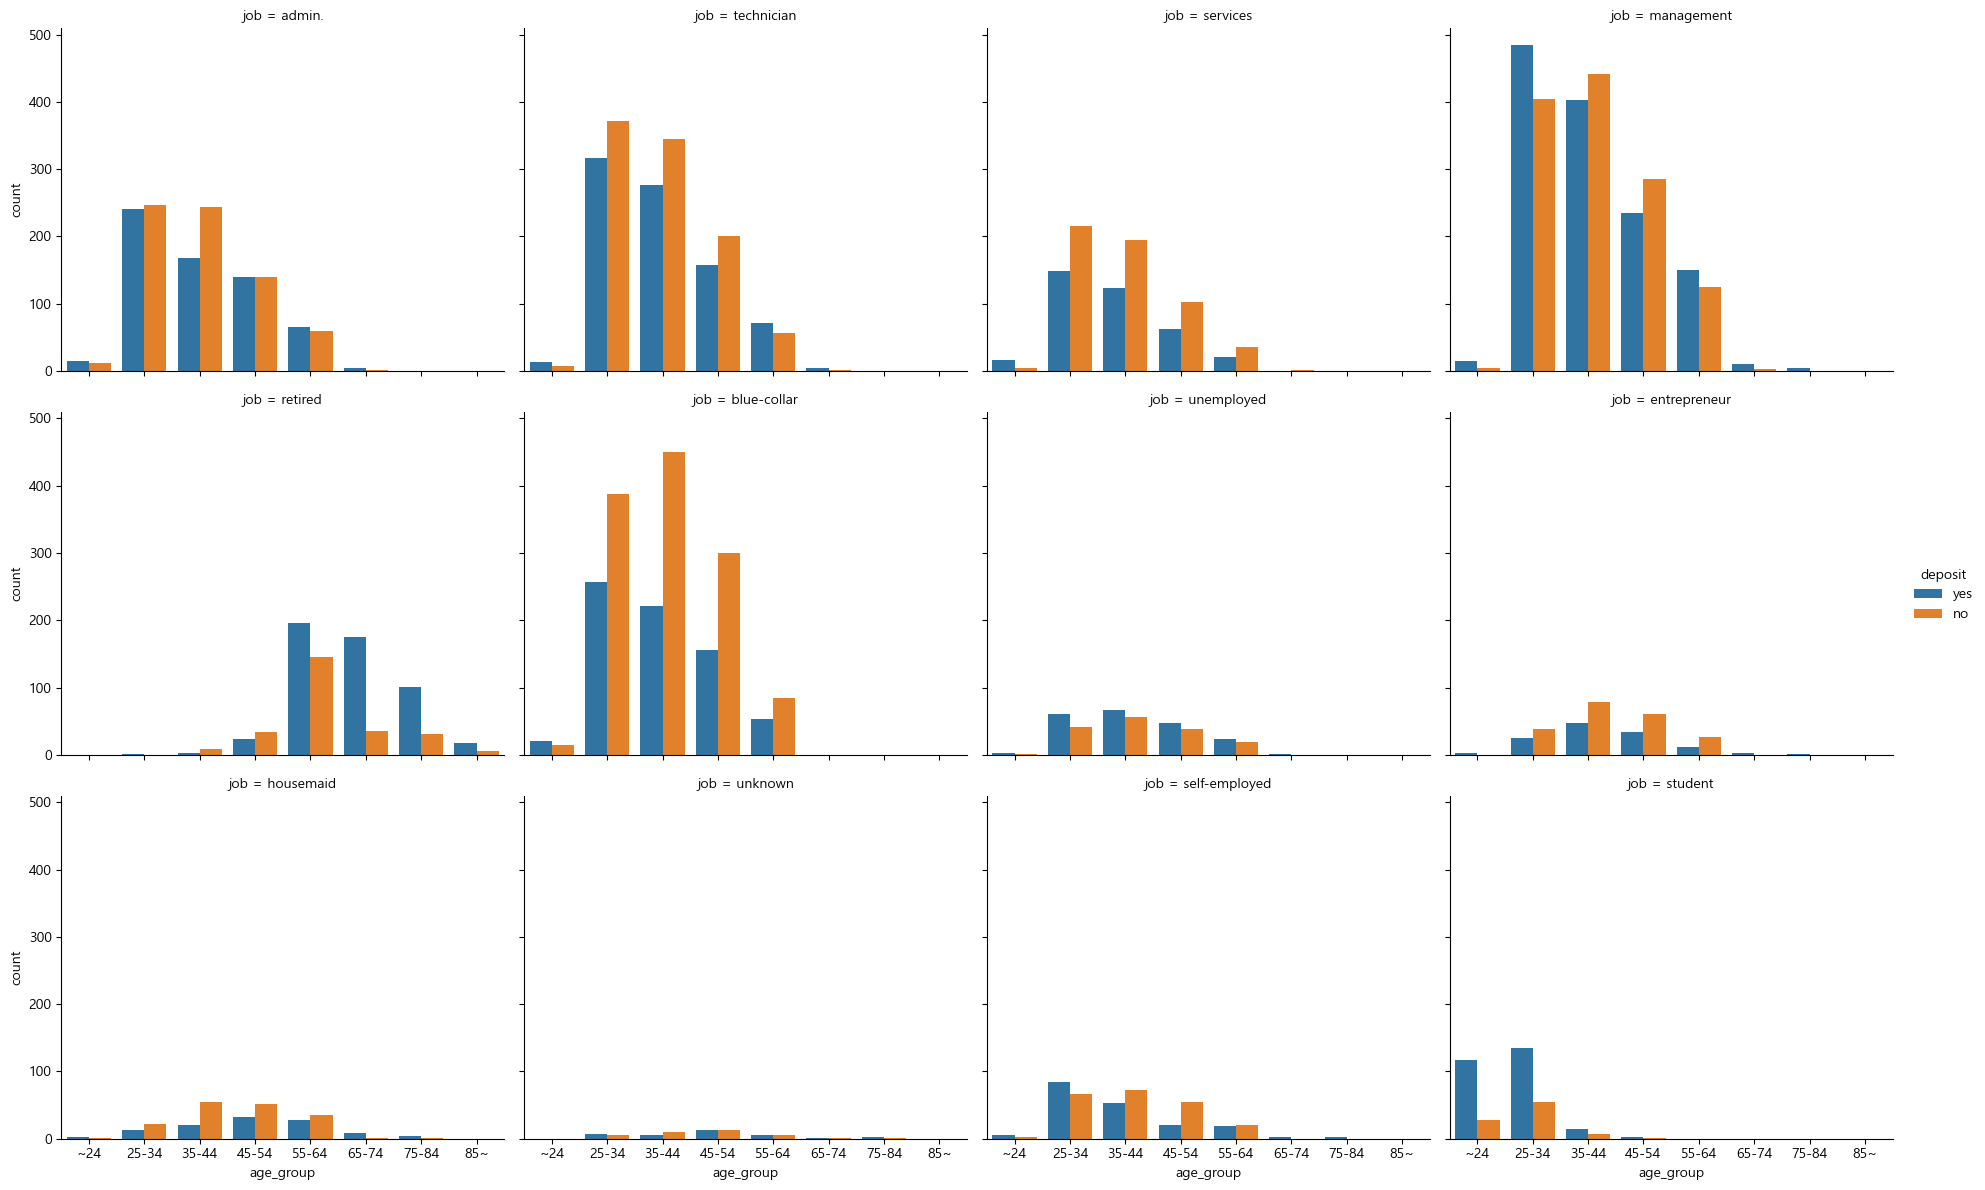

In [770]:
# 직업별로 서브플롯을 생성하여 연령대별 가입 여부 확인
sns.catplot(
    data=df, 
    x='age_group', 
    hue='deposit', 
    col='job', 
    kind='count', 
    col_wrap=4, # 한 줄에 4개씩 배치
    height=4, 
    aspect=1.2,
)

- education

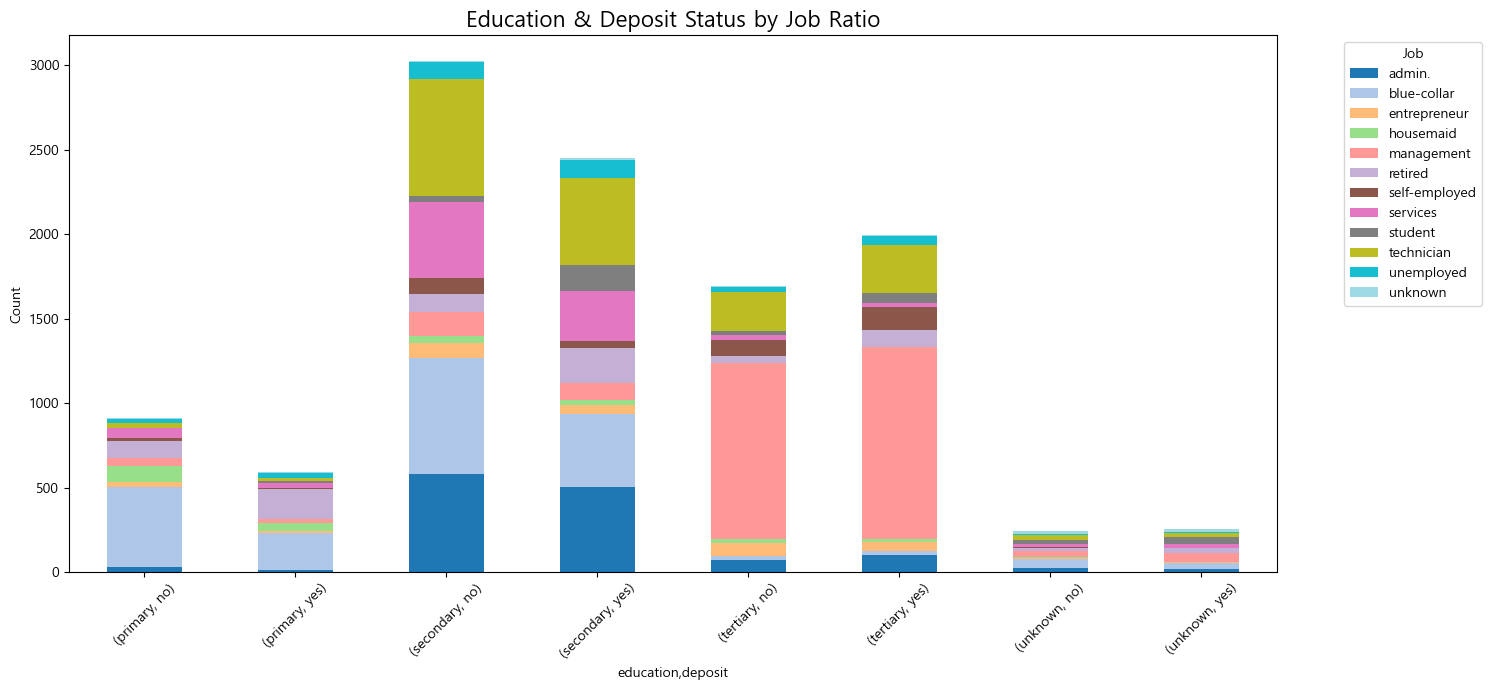

In [771]:
# 연령대와 예금 여부별로 직업군을 집계
stacked_data = df.groupby(['education', 'deposit', 'job']).size().unstack(fill_value=0)

# 시각화
stacked_data.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='tab20')

plt.title("Education & Deposit Status by Job Ratio", fontsize=16)
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title='Job', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

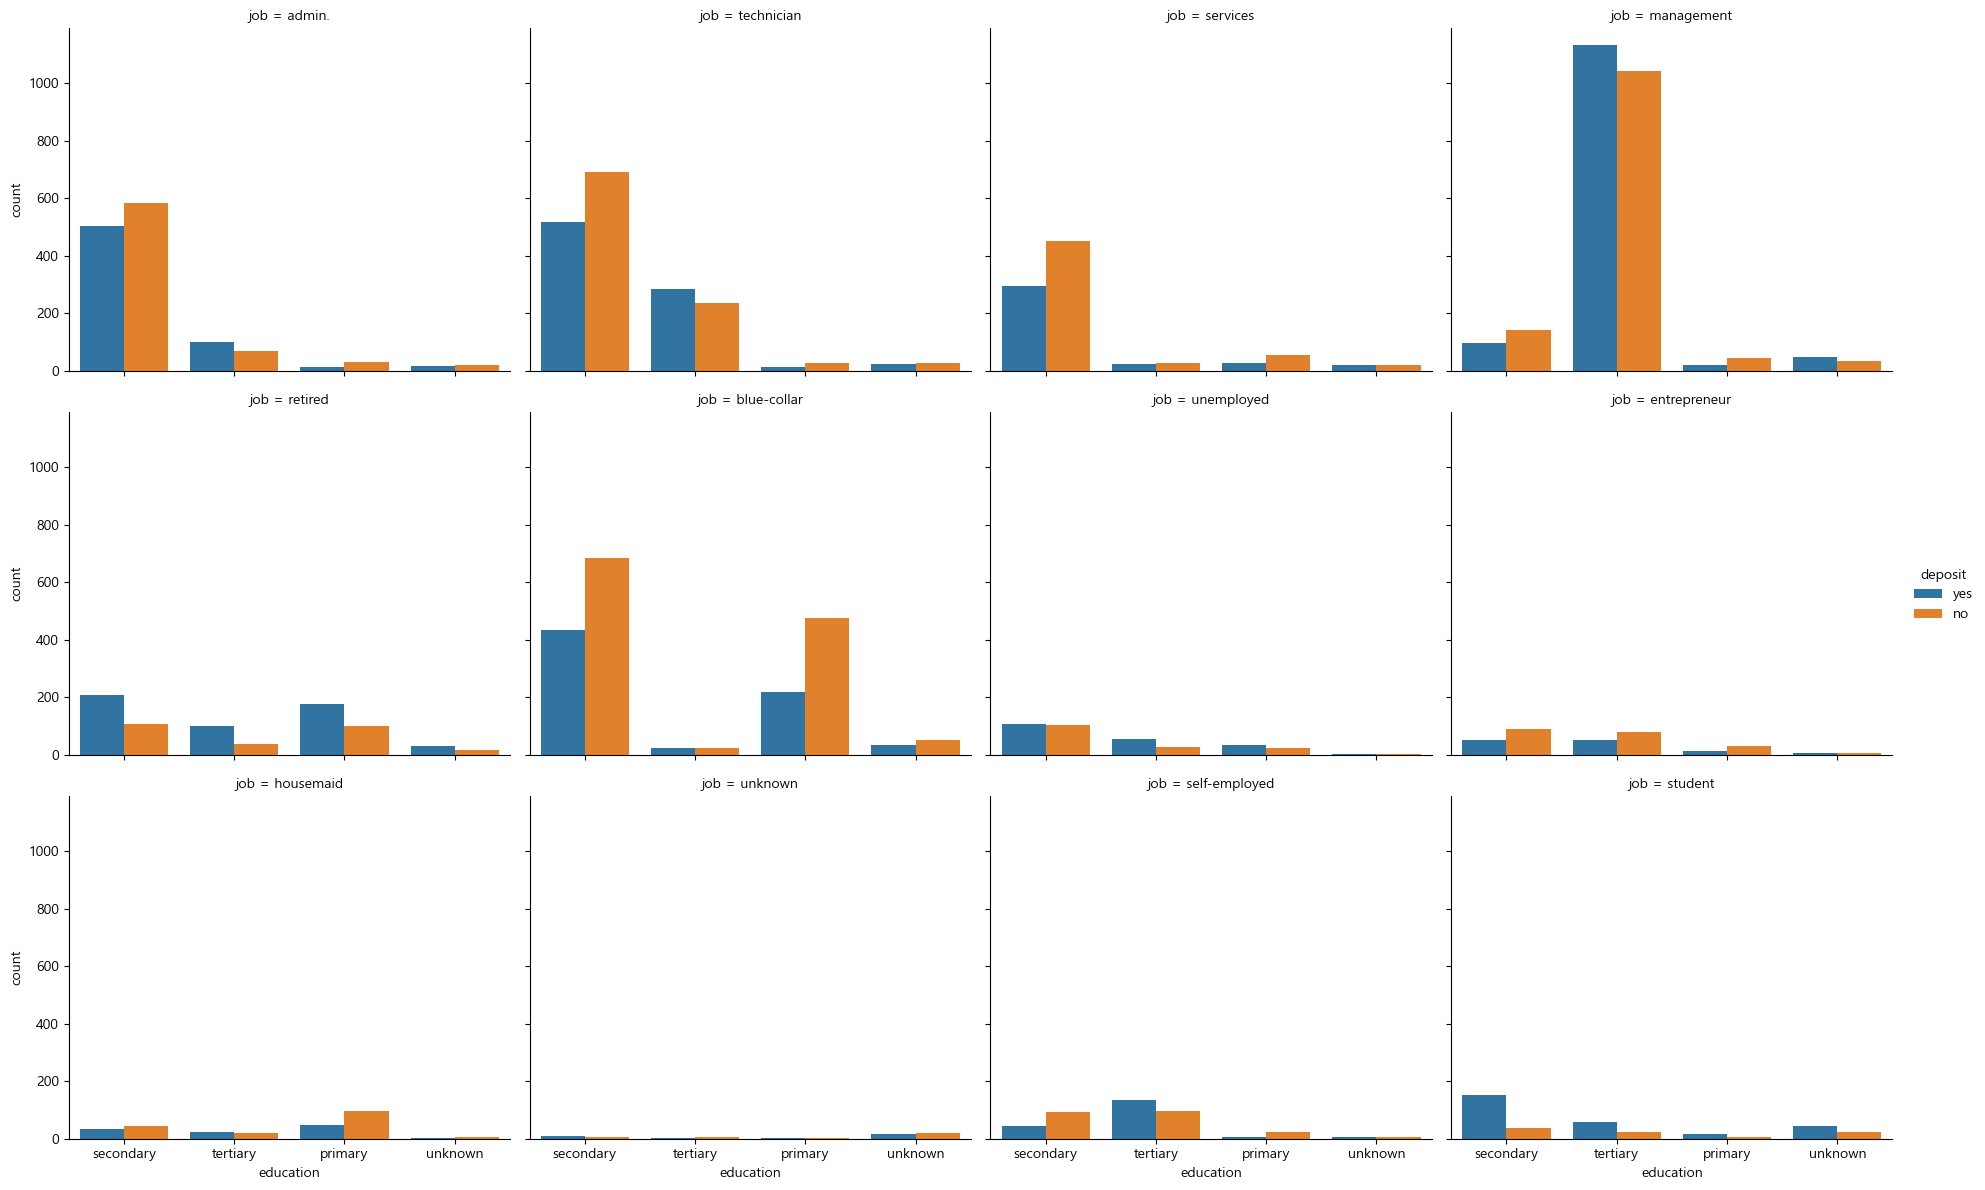

In [772]:
# 직업별로 서브플롯을 생성하여 연령대별 가입 여부 확인
sns.catplot(
    data=df, 
    x='education', 
    hue='deposit', 
    col='job', 
    kind='count', 
    col_wrap=4, # 한 줄에 4개씩 배치
    height=4, 
    aspect=1.2,
)

#### marital

### 은행 마케팅 관련

#### campaign

In [773]:
# 1. 계산 로직 함수 (기존과 동일)
def calculate_asset_score(row):
    base_balance = row['balance']
    penalty = 1.0
    if row['housing'] == 'yes': penalty -= 0.3
    if row['loan'] == 'yes': penalty -= 0.5
    return base_balance * max(penalty, 0.1)

# 2. 원본 df를 수정하지 않고, 분석용 임시 데이터프레임 생성
# assign을 사용하면 이 코드 블록 내에서만 존재하는 새로운 객체가 반환됩니다.
temp_analysis_df = df.assign(
    # (1) 실질 가용 자산 지수 계산
    net_asset_score = lambda x: x.apply(calculate_asset_score, axis=1).astype('float32'),
    
    # (2) 부채 여부 통합 (이진 변수)
    has_loan = lambda x: np.where((x['housing'] == 'yes') | (x['loan'] == 'yes'), 1, 0).astype('int8'),
    
    # (3) 대출 위험도 점수
    debt_intensity = lambda x: x.apply(
        lambda r: (1 if r['housing'] == 'yes' else 0) + (2 if r['loan'] == 'yes' else 0), axis=1
    ).astype('int8')
)

# 3. 결과 확인 (df를 출력해보면 새 컬럼이 없는 것을 확인할 수 있습니다)
print("--- [임시 분석용 데이터프레임 상위 5개] ---")
print(temp_analysis_df[['balance', 'housing', 'loan', 'net_asset_score', 'has_loan']].head())

--- [임시 분석용 데이터프레임 상위 5개] ---
   balance housing loan  net_asset_score  has_loan
0     2343     yes   no      1640.099976         1
1       45      no   no        45.000000         0
2     1270     yes   no       889.000000         1
3     2476     yes   no      1733.199951         1
4      184      no   no       184.000000         0



--- [Fatigue Index 통계량] ---
          count       mean        std  min  25%  50%  75%     max
deposit                                                          
no       5873.0  18.586243  88.741432  1.0  1.0  4.0  9.0  3969.0
yes      5289.0   8.276801  28.978809  1.0  1.0  4.0  9.0  1024.0


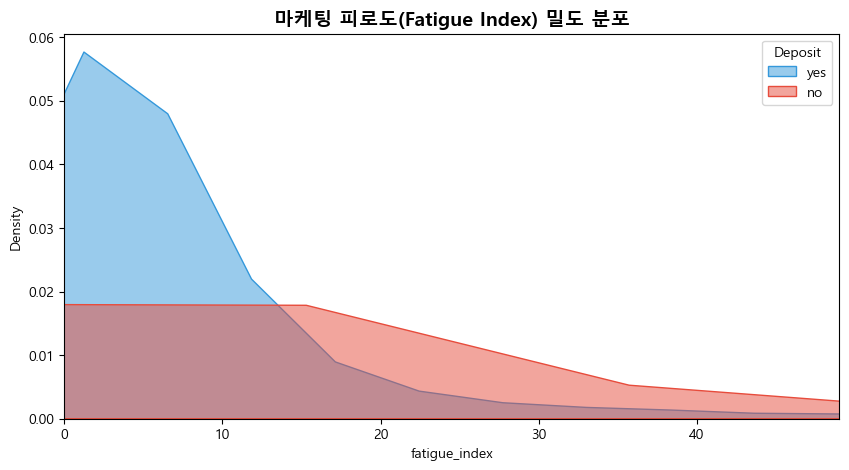

In [774]:
# [Campaign 심화] 지표 생성 및 통계 확인
temp_analysis_df = temp_analysis_df.assign(
    fatigue_index = lambda x: (x['campaign'] ** 2).astype('float32')
)

print("\n--- [Fatigue Index 통계량] ---")
print(temp_analysis_df.groupby('deposit')['fatigue_index'].describe())

# 시각화 (KDE 밀도 그래프)
plt.figure(figsize=(10, 5))
for status, color in zip(['yes', 'no'], ['#3498DB', '#E74C3C']):
    sns.kdeplot(temp_analysis_df[temp_analysis_df['deposit'] == status]['fatigue_index'], 
                label=status, fill=True, color=color, alpha=0.5)
plt.title('마케팅 피로도(Fatigue Index) 밀도 분포', fontsize=14, fontweight='bold')
plt.xlim(0, temp_analysis_df['fatigue_index'].quantile(0.95))
plt.legend(title='Deposit')
plt.show()

**최적 접촉 횟수 구하기**

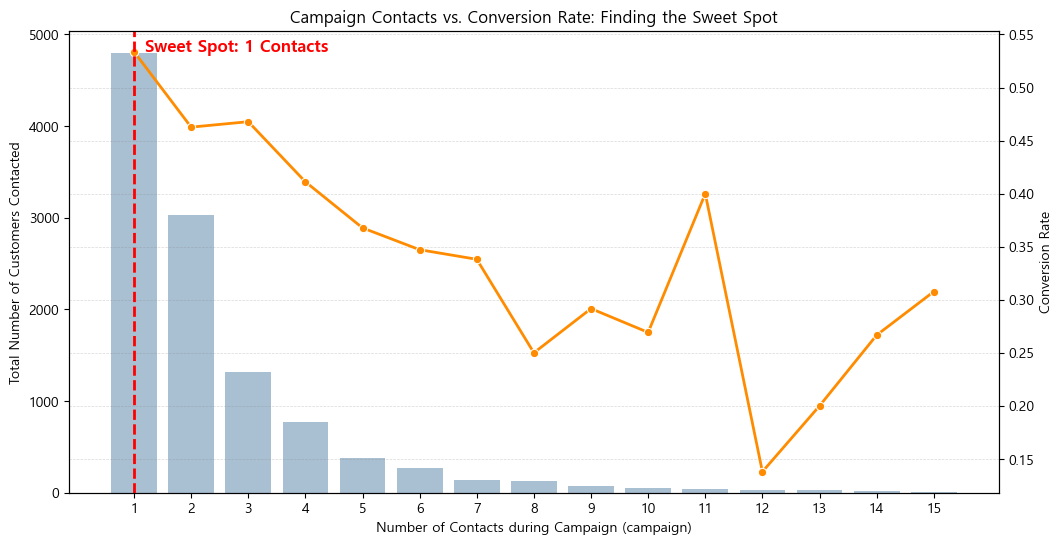

In [775]:
# 1. campaign(연락 횟수)별 가입률 및 통화 건수 집계
campaign_stats = df.groupby('campaign')['deposit_bool'].agg(['count', 'mean']).reset_index()

# 2. 꼬리가 너무 길면(예: 50번 연락) 노이즈가 심하므로 15회 이하만 시각화
campaign_stats = campaign_stats[campaign_stats['campaign'] <= 15]

# 3. 변곡점(최대 가입률을 기록한 접촉 횟수) 찾기
optimal_contact = campaign_stats.loc[campaign_stats['mean'].idxmax(), 'campaign']
max_rate = campaign_stats['mean'].max()

# 4. 시각화 시작
fig, ax1 = plt.subplots(figsize=(12, 6))

# 막대 차트: 접촉 횟수별 총 고객 수 (Volume)
sns.barplot(data=campaign_stats, x='campaign', y='count', color='steelblue', alpha=0.5, ax=ax1)
ax1.set_ylabel('Total Number of Customers Contacted')
ax1.set_xlabel('Number of Contacts during Campaign (campaign)')

# 라인 차트: 접촉 횟수별 가입률 (Conversion Rate)
ax2 = ax1.twinx()
sns.lineplot(data=campaign_stats, x=campaign_stats.index, y='mean', marker='o', color='darkorange', linewidth=2, ax=ax2)
ax2.set_ylabel('Conversion Rate')

# 5. 변곡점 표시 (수직선 및 텍스트)
ax2.axvline(x=optimal_contact - 1, color='red', linestyle='--', linewidth=2) # 인덱스 보정(-1)
ax2.text(optimal_contact - 0.8, max_rate, f'Sweet Spot: {optimal_contact} Contacts', color='red', fontsize=12, fontweight='bold')

plt.title('Campaign Contacts vs. Conversion Rate: Finding the Sweet Spot')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.show()

여기까지의 여정
- month 칼럼을 바탕으로 여러 칼럼에 대해 시계열 EDA 진행 -> 어? campaign 칼럼에서 ~~~ 한 특징이 보이네? -> 확인해보자

해석 및 제안
- 캠페인당 1회 접촉이 가장 높은 deposit 전환 효율을 보임
- 한명의 고객당 최대 3회까지 접촉을 진행하고, 그 이후로는 다른 고객에 집중하는 쪽이 캠페인 효율을 높이는 방법이다.
    - 추가 진행 필요 : n회 접촉마다 deposit yes 전환 효율이 어떻게 변하는지 구하기

#### duration

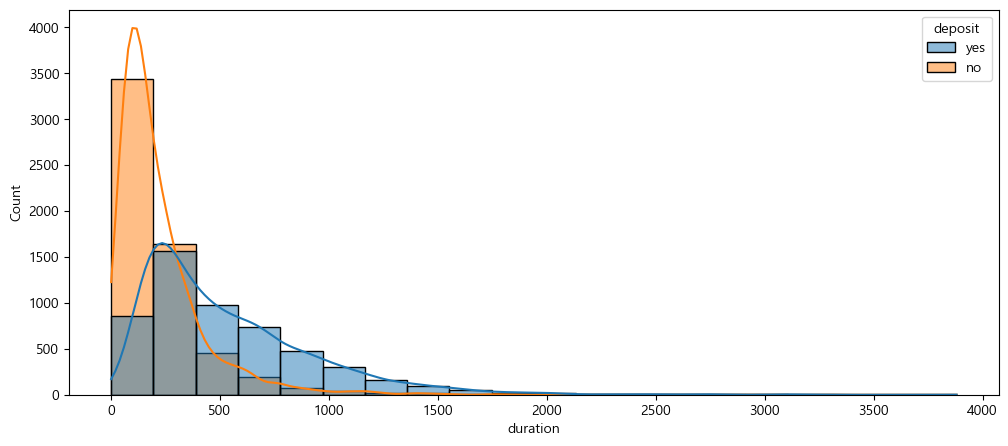

In [776]:
# deposit yes/no 별 duration 분포 시각화
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='duration', hue='deposit', kde=True, bins=20)
plt.show()

> duration 값이 클수록 deposit yes의 비율이 높게 나타남

### 자산 관련 칼럼 시각화

#### balance

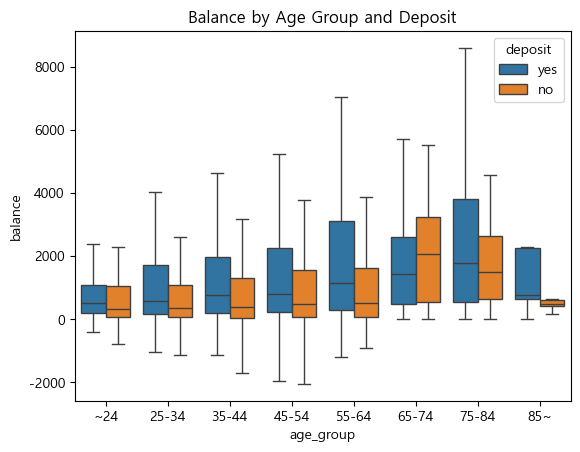

In [777]:
# balance 칼럼의 age_group과 deposit에 따른 분포 박스플롯
sns.boxplot(data=df, x='age_group', y='balance', hue='deposit', showfliers=False)
plt.title("Balance by Age Group and Deposit")
plt.show()

#### housing & loan & default

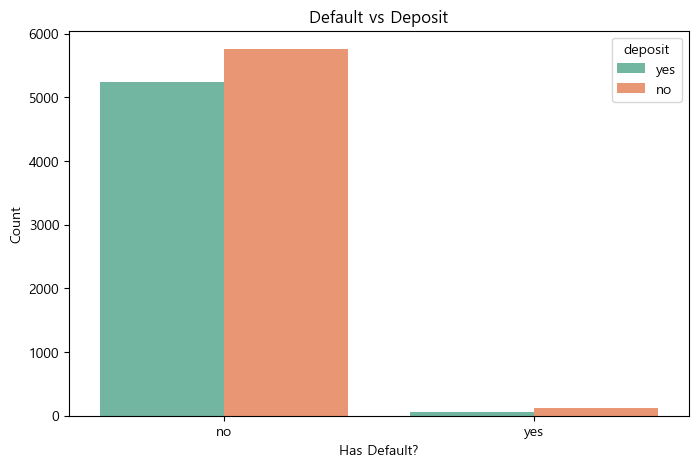

In [778]:
plt.figure(figsize=(8, 5))
# countplot으로 연체 여부에 따른 가입 여부 확인
sns.countplot(data=df, x='default', hue='deposit', palette='Set2')

plt.title('Default vs Deposit')
plt.xlabel('Has Default?')
plt.ylabel('Count')
plt.show()

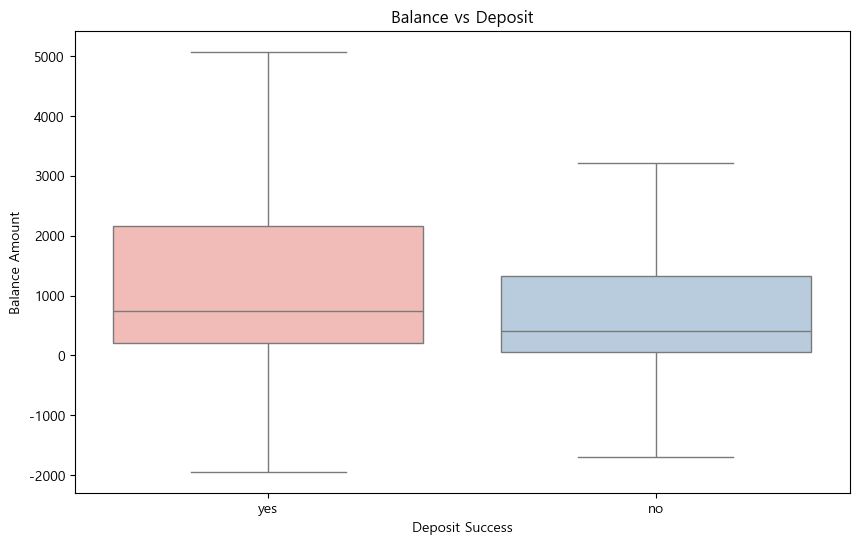

In [779]:
plt.figure(figsize=(10, 6))
# 잔고 분포 확인 (이상치 제외하고 가독성 높임)
sns.boxplot(data=df, x='deposit', y='balance', palette='Pastel1', showfliers=False)

plt.title('Balance vs Deposit')
plt.xlabel('Deposit Success')
plt.ylabel('Balance Amount')
plt.show()

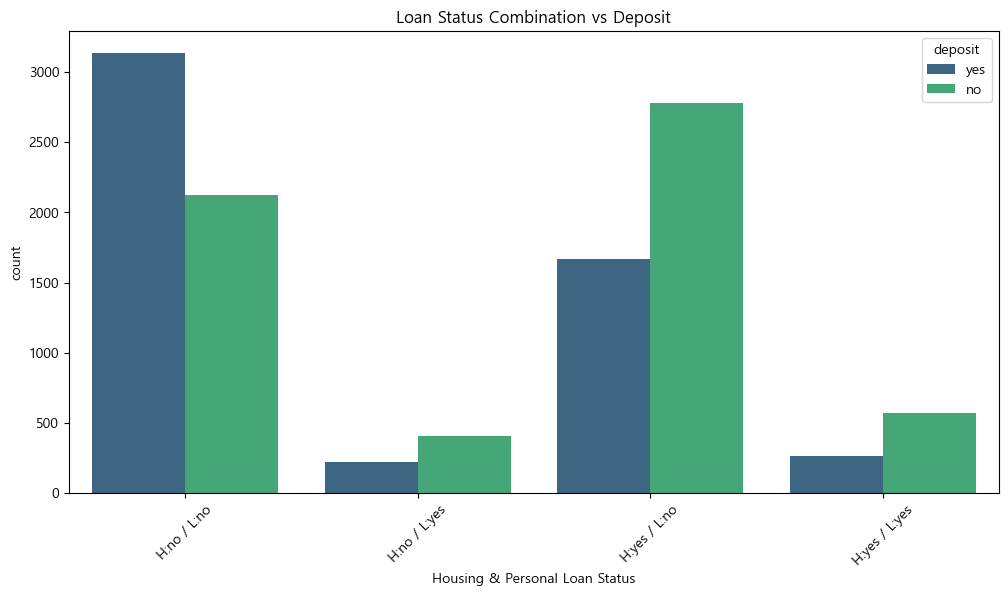

In [780]:
# 두 대출 상태를 합친 새로운 칼럼 생성
df['loan_status'] = 'H:' + df['housing'] + ' / L:' + df['loan']

plt.figure(figsize=(12, 6))
# 대출 조합별 가입 비율 확인
sns.countplot(data=df, x='loan_status', hue='deposit', 
              order=sorted(df['loan_status'].unique()), palette='viridis')

plt.title('Loan Status Combination vs Deposit')
plt.xticks(rotation=45)
plt.xlabel('Housing & Personal Loan Status')
plt.show()

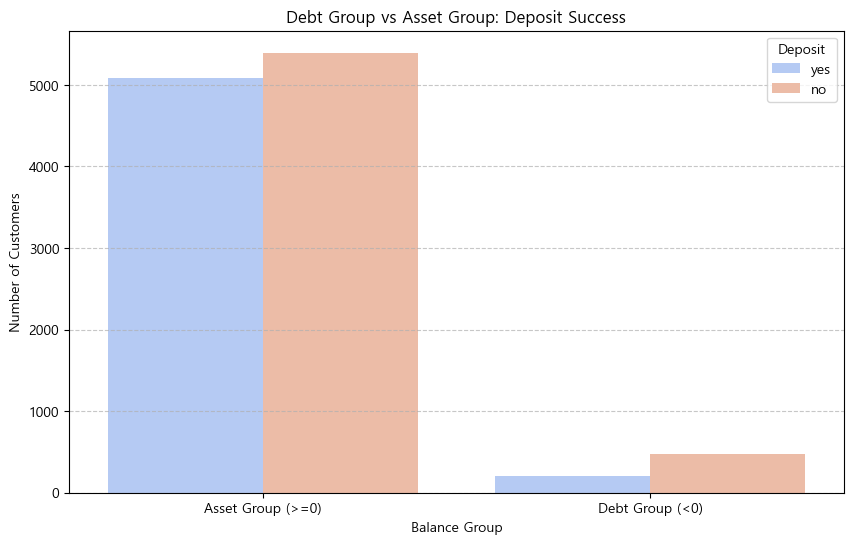

In [781]:
# [안전장치] balance가 0 미만이면 부채 그룹, 아니면 자산 그룹으로 분류
df['balance_group'] = np.where(df['balance'] < 0, 'Debt Group (<0)', 'Asset Group (>=0)')

plt.figure(figsize=(10, 6))

# 그룹별 가입 여부 카운트 시각화
ax = sns.countplot(data=df, x='balance_group', hue='deposit', palette='coolwarm')

# 그래프 스타일링
plt.title('Debt Group vs Asset Group: Deposit Success')
plt.xlabel('Balance Group')
plt.ylabel('Number of Customers')
plt.legend(title='Deposit')

# 가독성을 위한 점선 추가
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [782]:
# 1. 그룹이 제대로 나누어졌는지 확인 (결측치 포함)
print("그룹별 데이터 분포:")
print(df['balance_group'].value_counts(dropna=False))

# 2. 실제 데이터 매핑 결과 확인
print("\n데이터 샘플 확인:")
print(df[['balance', 'balance_group']].head())

그룹별 데이터 분포:
balance_group
Asset Group (>=0)    10474
Debt Group (<0)        688
Name: count, dtype: int64

데이터 샘플 확인:
   balance      balance_group
0     2343  Asset Group (>=0)
1       45  Asset Group (>=0)
2     1270  Asset Group (>=0)
3     2476  Asset Group (>=0)
4      184  Asset Group (>=0)


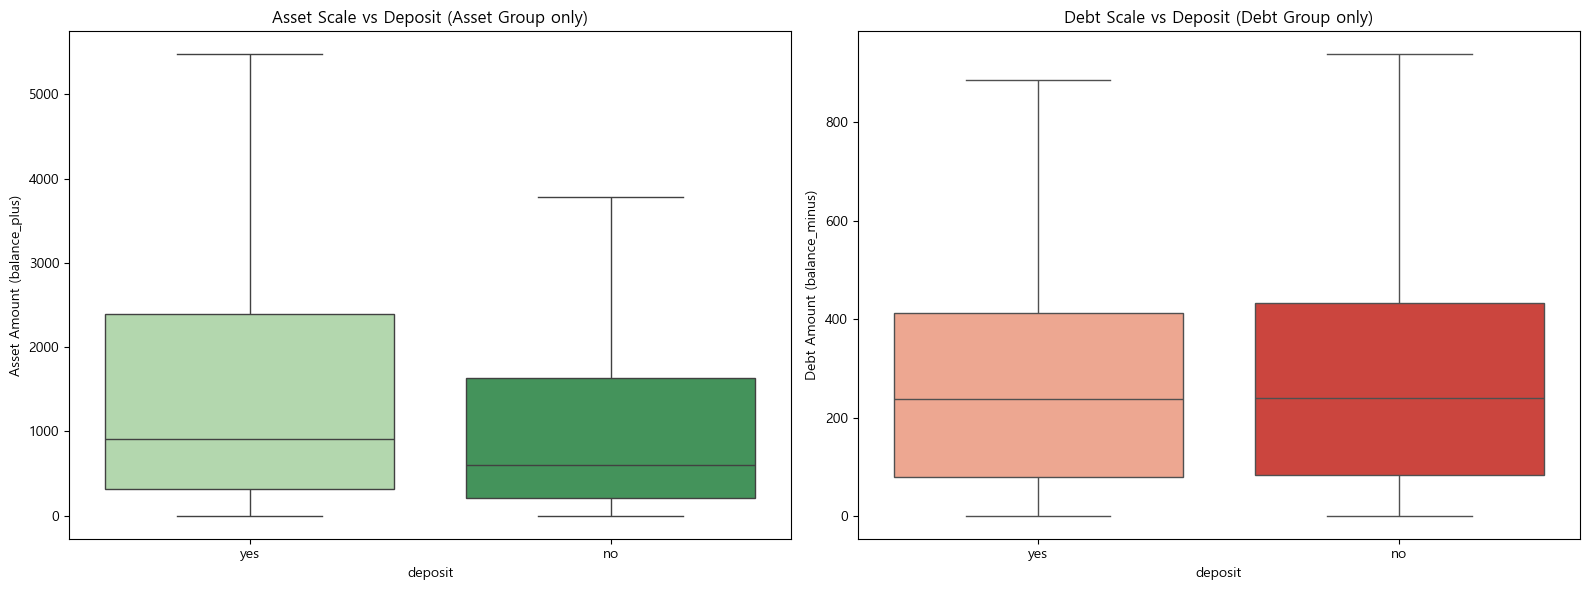

In [783]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 자산 그룹 내에서의 잔고 크기와 가입 관계 (balance_plus 사용)
sns.boxplot(data=df[df['balance_plus'] > 0], x='deposit', y='balance_plus', 
            palette='Greens', showfliers=False, ax=axes[0])
axes[0].set_title('Asset Scale vs Deposit (Asset Group only)')
axes[0].set_ylabel('Asset Amount (balance_plus)')

# 오른쪽: 부채 그룹 내에서의 빚 크기와 가입 관계 (balance_minus 사용)
sns.boxplot(data=df[df['balance_minus'] > 0], x='deposit', y='balance_minus', 
            palette='Reds', showfliers=False, ax=axes[1])
axes[1].set_title('Debt Scale vs Deposit (Debt Group only)')
axes[1].set_ylabel('Debt Amount (balance_minus)')

plt.tight_layout()
plt.show()

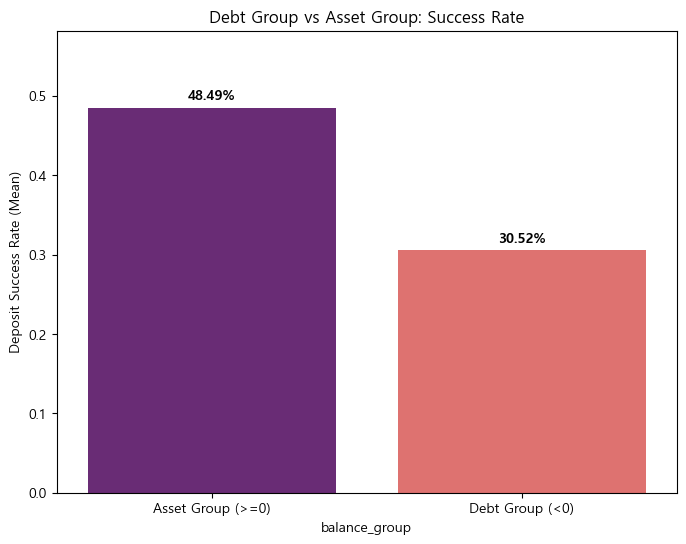

In [784]:
# 그룹별 가입 확률 계산
conversion_rates = df.groupby('balance_group')['deposit_bool'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=conversion_rates, x='balance_group', y='deposit_bool', palette='magma')

plt.title('Debt Group vs Asset Group: Success Rate')
plt.ylabel('Deposit Success Rate (Mean)')
plt.ylim(0, conversion_rates['deposit_bool'].max() * 1.2) # 여유 공간 확보

# 막대 위에 수치 표시
for i, rate in enumerate(conversion_rates['deposit_bool']):
    plt.text(i, rate + 0.01, f'{rate:.2%}', ha='center', fontweight='bold')

plt.show()

**시각화 해석**
- 발견: 20대 이탈률이 40대 대비 2.3배 높음
- 가설: 초기 온보딩 경험이 장기 잔존에 영향을 줄 수 있음
- 다음 확인: 가입 후 7일 이내 행동 패턴과 교차 분석 필요

In [785]:
# 1. 기초 가공 및 함수 기반 칼럼 추가
def calculate_asset_score(row):
    base_balance = row['balance']
    penalty = 1.0
    if row['housing'] == 'yes': penalty -= 0.3
    if row['loan'] == 'yes': penalty -= 0.5
    return base_balance * max(penalty, 0.1)

# (1) 실질 가용 자산 지수
df['net_asset_score'] = df.apply(calculate_asset_score, axis=1).astype('float32')

# (2) 부채 여부 통합 (이진 변수)
df['has_loan'] = np.where((df['housing'] == 'yes') | (df['loan'] == 'yes'), 1, 0).astype('int8')

# (3) 대출 위험도 점수
df['debt_intensity'] = df.apply(
    lambda r: (1 if r['housing'] == 'yes' else 0) + (2 if r['loan'] == 'yes' else 0), axis=1
).astype('int8')

# 2. 로그 변환을 위한 Offset 계산
balance_min = df['balance'].min()
offset = abs(balance_min) + 1 if balance_min <= 0 else 1

# 3. 추가 지표 계산
# (1) total_debt_load: 부채 가중치 / 자산 규모(log)
df['total_debt_load'] = (
    ((df['housing'] == 'yes').astype(int) * 1 + (df['loan'] == 'yes').astype(int) * 2) / 
    np.log1p(df['balance'] + offset)
).astype('float32')

# (2) balance_stability: 잔고 안정성
df['balance_stability'] = (df['balance'] / (df['is_balance_minus'] + 1)).astype('float32')

# (3) success_weight: 과거 캠페인 성공 가중치
df['success_weight'] = (df['previous'] / (df['campaign'] + df['previous'] + 1)).astype('float32')

# 4. 결과 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   age                11162 non-null  int64   
 1   job                11162 non-null  object  
 2   marital            11162 non-null  object  
 3   education          11162 non-null  object  
 4   default            11162 non-null  object  
 5   balance            11162 non-null  int64   
 6   housing            11162 non-null  object  
 7   loan               11162 non-null  object  
 8   contact            11162 non-null  object  
 9   day                11162 non-null  int64   
 10  month              11162 non-null  object  
 11  duration           11162 non-null  int64   
 12  campaign           11162 non-null  int64   
 13  pdays              11162 non-null  int64   
 14  previous           11162 non-null  int64   
 15  poutcome           11162 non-null  object  
 16  depo

## 인코딩 & 스케일링

### 모델 학습에 불필요한 칼럼 삭제
1. balance 관련 칼럼 : balance, balance_log, balance_plus, balance_minus 삭제 / balance_plus_log, balance_minus_log, is_balance_minus 사용
2. age : age, age_group 사용
3. pdays : pdays 삭제 / pdays_binary, pdays_group 사용
4. day, month : 그대로 사용
5. duration : 삭제(leakage 위험)
6. 자산 관련 칼럼 : loan_status, net_asset_score, has_loan, debt_intensity, total_debt_load, balance_stability, success_weight 사용

- CASE 1 : train_test_split 에서 stratify=target 설정 X
    - 추가 진행 없음
- CASE 2 : train_test_split 에서 stratify=target 설정 O
    - 2-A : PHC cols
    - 2-B : LDK cols

In [786]:
df.drop(columns=['balance', 'balance_log', 'balance_plus', 'balance_minus', 'pdays', 
                'duration', 'deposit_bool', 'week', 'period', 'balance_group'], inplace=True)
df.drop(columns=['loan', 'housing'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   age                11162 non-null  int64   
 1   job                11162 non-null  object  
 2   marital            11162 non-null  object  
 3   education          11162 non-null  object  
 4   default            11162 non-null  object  
 5   contact            11162 non-null  object  
 6   day                11162 non-null  int64   
 7   month              11162 non-null  object  
 8   campaign           11162 non-null  int64   
 9   previous           11162 non-null  int64   
 10  poutcome           11162 non-null  object  
 11  deposit            11162 non-null  object  
 12  age_group          11162 non-null  category
 13  pdays_binary       11162 non-null  object  
 14  pdays_group        11162 non-null  category
 15  is_balance_minus   11162 non-null  int32   
 16  bala

In [787]:
df['campaign_log'] = np.log1p(df['campaign'])
df['previous_log'] = np.log1p(df['previous'])
df.drop(columns=['campaign', 'previous'], inplace=True)

- 인코딩 전 최종 drop된 칼럼들

['balance', 'balance_log', 'balance_plus', 'balance_minus', 'pdays', 
                'duration', 'deposit_bool', 'week', 'period', 'balance_group',
                'loan', 'housing', 'campaign', 'previous']

In [788]:
df.head()

,age,job,marital,education,default,contact,day,month,poutcome,deposit,...,balance_minus_log,loan_status,net_asset_score,has_loan,debt_intensity,total_debt_load,balance_stability,success_weight,campaign_log,previous_log
0,59,admin.,married,secondary,no,unknown,5,may,unknown,yes,...,0.0,H:yes / L:no,1640.099976,1,1,0.109576,2343.0,0.0,0.693147,0.0
1,56,admin.,married,secondary,no,unknown,5,may,unknown,yes,...,0.0,H:no / L:no,45.000000,0,0,0.000000,45.0,0.0,0.693147,0.0
2,41,technician,married,secondary,no,unknown,5,may,unknown,yes,...,0.0,H:yes / L:no,889.000000,1,1,0.111087,1270.0,0.0,0.693147,0.0
3,55,services,married,secondary,no,unknown,5,may,unknown,yes,...,0.0,H:yes / L:no,1733.199951,1,1,0.109404,2476.0,0.0,0.693147,0.0
4,54,admin.,married,tertiary,no,unknown,5,may,unknown,yes,...,0.0,H:no / L:no,184.000000,0,0,0.000000,184.0,0.0,1.098612,0.0


## A_st : age_group drop

In [789]:
# # 다중공선성 해결 & 피처 중요도 기반 피처 제거
# # 1차 : age(F_Imp 6.782321, VIF 158.844716) / age_group(F_Imp 1.732772, VIF 54.752586) -> F_Imp 높은 age 유지
# df.drop(columns=['age_group'], inplace=True)


# # -------------------------------------------
# from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# # # 1-1. Label Encoding (Target 및 이진 변수)
# # le = LabelEncoder()
# # for col in ['deposit', 'default', 'pdays_binary']:
# #     df[col] = le.fit_transform(df[col])

# # 1-2. 명시적 매핑 (Target 및 이진 변수)
# # LabelEncoder 대신 map을 사용하여 0과 1의 의미를 직접 지정합니다.
# df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0}).astype('int8')
# df['default'] = df['default'].map({'yes': 1, 'no': 0}).astype('int8')

# # pdays_binary는 앞서 정의한 범주명('-1', 'other')에 맞춰 매핑합니다.
# df['pdays_binary'] = df['pdays_binary'].map({'other': 1, '-1': 0}).astype('int8')

# # 2. Ordinal Encoding (교육 수준 - 직접 순서 지정)
# edu_order = ['unknown', 'primary', 'secondary', 'tertiary']
# ord_enc = OrdinalEncoder(categories=[edu_order])
# df['education'] = ord_enc.fit_transform(df[['education']])

# encoder = OrdinalEncoder(categories=[month_order])
# df['month_encoded'] = encoder.fit_transform(df[['month']])
# df.drop(columns=['month'], inplace=True)

# # 3. pdays_group (이미 Category 타입이므로 cat.codes 활용 가능)
# df['pdays_group'] = df['pdays_group'].cat.codes

# # 4. One-Hot Encoding (범주가 적은 변수)
# df = pd.get_dummies(df, columns=['marital', 'loan_status'], drop_first=True, dtype=int)

# # -------------------------------------------
# train = df.drop(columns=['deposit'])
# target = df['deposit']
# print(train.shape, target.shape)


# # -------------------------------------------
# x_train, x_test, y_train, y_test = train_test_split(
#     train, 
#     target, 
#     test_size=0.2, 
#     random_state=42,
#     stratify=target
# )

# # # 5. Target Encoding (가입률 정보를 모델에 직접 주입)
# # # 주의: 실제로는 train/test 분리 후 train의 평균값으로 처리하는 것이 정석입니다.
# # for col in ['job', 'poutcome', 'contact']:
# #     target_mean = df.groupby(col)['deposit'].mean() # 1번에서 deposit을 0,1로 바꿨기에 가능
# #     df[f'{col}_encoded'] = df[col].map(target_mean)
# #     df.drop(columns=[col], inplace=True)

# # 5. 1~4번 인코딩 및 분리 완료 후 (x_train, x_test 분리된 상태)
# target_cols = ['job', 'poutcome', 'contact']
# overall_mean = y_train.mean()
# for col in target_cols:
#     # 오직 훈련 데이터(y_train)에서만 각 범주별 평균 가입률 계산
#     target_mean = y_train.groupby(x_train[col]).mean()

#     # 훈련 데이터 변환
#     x_train[f'{col}_encoded'] = x_train[col].map(target_mean)
    
#     # 테스트 데이터 변환 (훈련 데이터에서 얻은 평균값을 그대로 사용, 훈련 데이터에 없는 범주는 전체 평균으로 처리)
#     x_test[f'{col}_encoded'] = x_test[col].map(target_mean).fillna(overall_mean)
    
#     # 원본 칼럼 삭제
#     x_train.drop(columns=[col], inplace=True)
#     x_test.drop(columns=[col], inplace=True)

# # # 6. Target Encoding 후 원본 삭제까지 완료된 상태에서 실행
# # import re
# # x_train.columns = [re.sub(r'[^\w\s]', '_', col).replace(' ', '_') for col in x_train.columns]
# # x_test.columns = [re.sub(r'[^\w\s]', '_', col).replace(' ', '_') for col in x_test.columns]

# # ---------------------------------------------------
# # 인코딩 결과
# print(x_train.shape, x_test.shape, y_train.shape, y_test.shape) # (8929, 27) (2233, 27) (8929,) (2233,)
# print(x_train.info())
# # print(x_train.columns.tolist())

# #--------------------------------------------
# from sklearn.pipeline import make_pipeline
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, Normalizer, Binarizer, QuantileTransformer
# from sklearn.linear_model import LogisticRegression
# from lightgbm import LGBMClassifier
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
# from catboost import CatBoostClassifier
# from xgboost import XGBClassifier


# # 1. 평가할 모델 딕셔너리 생성
# models = {
#     "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000),
#     "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
#     "LightGBM": LGBMClassifier(random_state=42, n_estimators=100),
#     "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
#     "XGBoost": XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss'),
#     "GradientBoosting": GradientBoostingClassifier(random_state=42, n_estimators=100),
#     "AdaBoost": AdaBoostClassifier(random_state=42, n_estimators=100)
# }

# # 2. 평가할 스케일러 리스트 (None을 추가해 스케일링 안 한 기본 상태도 비교)
# scaler_cls_list = [None, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, Normalizer, Binarizer, QuantileTransformer]

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# def evaluate_models_and_scalers(models_dict, scalers_list, x, y, cv, scoring="f1_macro"):
#     results = []
    
#     for model_name, model in models_dict.items():
#         for scaler_cls in scalers_list:
            
#             # 스케일러 이름 추출 (None 처리 포함)
#             scaler_name = scaler_cls.__name__ if scaler_cls else "None (No Scaling)"
            
#             # 파이프라인 생성 (데이터 누수 방지 핵심!)
#             if scaler_cls:
#                 pipeline = make_pipeline(scaler_cls(), model)
#             else:
#                 pipeline = make_pipeline(model) # 스케일러 없는 경우
            
#             # Cross Validation 진행 (파이프라인 자체를 모델처럼 넣음)
#             scores = cross_val_score(pipeline, x, y, scoring=scoring, cv=cv, n_jobs=-1)
#             mean_score = scores.mean()
            
#             # 결과 저장
#             results.append({
#                 "Model": model_name,
#                 "Scaler": scaler_name,
#                 f"{scoring}_score": mean_score
#             })
#             print(f"[{model_name}] + [{scaler_name}] 완료: {mean_score:.4f}")

#     # 데이터프레임으로 변환 후 점수 기준 내림차순 정렬
#     results_df = pd.DataFrame(results).sort_values(by=f"{scoring}_score", ascending=False)
#     return results_df

# # ⚠️ 주의: 함수를 호출할 때 이미 스케일링된 x_train_scaled가 아니라, 
# # 인코딩만 완료된 순수한 x_train을 넣으셔야 합니다!
# print("--- 모델 및 스케일러 조합 성능 평가 시작 ---")
# final_results = evaluate_models_and_scalers(models, scaler_cls_list, x_train, y_train, cv, "f1_macro")

# print("\n--- 🏆 최종 순위표 ---")
# display(final_results) # 주피터 노트북 환경이라면 display 사용, 아니면 print(final_results)


# # --------------------------------------------------
# # 1위 조합으로 간이 학습
# cat_final = CatBoostClassifier(random_state=42, n_estimators=100)
# cat_final_pipeline = make_pipeline(PowerTransformer(), cat_final)
# cat_final_pipeline.fit(x_train, y_train)

# # 중요도 추출 및 데이터프레임화
# importances = pd.DataFrame({
#     'feature': x_train.columns,
#     'importance': cat_final_pipeline.named_steps['catboostclassifier'].feature_importances_
# }).sort_values(by='importance', ascending=False)

# # 시각화
# plt.figure(figsize=(10, 8))
# sns.barplot(x='importance', y='feature', data=importances)
# plt.title('CatBoost Feature Importance')
# plt.show()

# print(importances)


# # ---------------------------------------------------
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# # VIF 계산 함수
# def check_vif(df):
#     vif_df = pd.DataFrame()
#     vif_df["feature"] = df.columns
#     vif_df["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
#     return vif_df.sort_values(by="VIF", ascending=False)

# # 인코딩이 완료된 x_train에 대해 확인
# vif_results = check_vif(x_train)
# print(vif_results)

### Feature Selection
- Feature Importance & VIF 확인 이후

In [790]:
# 다중공선성 해결 & 피처 중요도 기반 피처 제거
# 1차 : age(F_Imp 6.782321, VIF 158.844716) / age_group(F_Imp 1.732772, VIF 54.752586) -> F_Imp 높은 age 유지
df.drop(columns=['age_group'], inplace=True)

# 2차-1 : has_loan , debt_intensity 제거 -> 두 변수 모두 loan_status로 설명 가능
df.drop(columns=['has_loan', 'debt_intensity'], inplace=True)
# 2차-2 : is_balance_minus 제거
df.drop(columns=['is_balance_minus'], inplace=True)
#### 2차 feature selection 결과 -> VIF inf값 해결

# 3차 : loan_status_H_yes_L_yes, pdays_binary, success_weight, balance_stability 삭제 -> F_Imp 낮고 VIF 높은 변수들 제거
# df.drop(columns=['loan_status_H_yes_L_yes', 'pdays_binary', 'success_weight', 'balance_stability'], inplace=True)
df.drop(columns=['pdays_binary', 'success_weight', 'balance_stability'], inplace=True)

In [791]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'contact', 'day',
       'month', 'poutcome', 'deposit', 'pdays_group', 'balance_plus_log',
       'balance_minus_log', 'loan_status', 'net_asset_score',
       'total_debt_load', 'campaign_log', 'previous_log'],
      dtype='object')

### 인코딩

In [792]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# # 1-1. Label Encoding (Target 및 이진 변수)
# le = LabelEncoder()
# for col in ['deposit', 'default', 'pdays_binary']:
#     df[col] = le.fit_transform(df[col])

# 1-2. 명시적 매핑 (Target 및 이진 변수)
# LabelEncoder 대신 map을 사용하여 0과 1의 의미를 직접 지정합니다.
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0}).astype('int8')
df['default'] = df['default'].map({'yes': 1, 'no': 0}).astype('int8')

# pdays_binary는 앞서 정의한 범주명('-1', 'other')에 맞춰 매핑합니다.
# 3차 feature selection에서 pdays_binary 제거
# df['pdays_binary'] = df['pdays_binary'].map({'other': 1, '-1': 0}).astype('int8')

# 2. Ordinal Encoding (교육 수준 - 직접 순서 지정)
edu_order = ['unknown', 'primary', 'secondary', 'tertiary']
ord_enc = OrdinalEncoder(categories=[edu_order])
df['education'] = ord_enc.fit_transform(df[['education']])

encoder = OrdinalEncoder(categories=[month_order])
df['month_encoded'] = encoder.fit_transform(df[['month']])
df.drop(columns=['month'], inplace=True)

# 3. age_group & pdays_group (이미 Category 타입이므로 cat.codes 활용 가능)
# 1차 feture select 로 age_group 제거
# df['age_group'] = df['age_group'].cat.codes
df['pdays_group'] = df['pdays_group'].cat.codes

# 4. One-Hot Encoding (범주가 적은 변수)
df = pd.get_dummies(df, columns=['marital', 'loan_status'], drop_first=True, dtype=int)

In [793]:
import re
df.columns = [re.sub(r'[^\w\s]', '_', col).replace(' ', '_') for col in df.columns]

df.drop(columns=['loan_status_H_yes___L_yes'], inplace=True)

In [794]:
# # 1. 인코더 생성 및 순서 주입
# encoder = OrdinalEncoder(categories=[month_order])

# # 2. 변환 (데이터프레임의 특정 칼럼을 직접 수정)
# df['month_encoded'] = encoder.fit_transform(df[['month']])

# # 3. 원본 삭제
# df.drop(columns=['month'], inplace=True)

In [795]:
train = df.drop(columns=['deposit'])
target = df['deposit']
print(train.shape, target.shape)

(11162, 19) (11162,)


In [796]:
x_train, x_test, y_train, y_test = train_test_split(
    train, 
    target, 
    test_size=0.2, 
    random_state=42,
    stratify=target
)

# # 5. Target Encoding (가입률 정보를 모델에 직접 주입)
# # 주의: 실제로는 train/test 분리 후 train의 평균값으로 처리하는 것이 정석입니다.
# for col in ['job', 'poutcome', 'contact']:
#     target_mean = df.groupby(col)['deposit'].mean() # 1번에서 deposit을 0,1로 바꿨기에 가능
#     df[f'{col}_encoded'] = df[col].map(target_mean)
#     df.drop(columns=[col], inplace=True)

# 5. 1~4번 인코딩 및 분리 완료 후 (x_train, x_test 분리된 상태)
target_cols = ['job', 'poutcome', 'contact']
overall_mean = y_train.mean()
for col in target_cols:
    # 오직 훈련 데이터(y_train)에서만 각 범주별 평균 가입률 계산
    target_mean = y_train.groupby(x_train[col]).mean()

    # 훈련 데이터 변환
    x_train[f'{col}_encoded'] = x_train[col].map(target_mean)
    
    # 테스트 데이터 변환 (훈련 데이터에서 얻은 평균값을 그대로 사용, 훈련 데이터에 없는 범주는 전체 평균으로 처리)
    x_test[f'{col}_encoded'] = x_test[col].map(target_mean).fillna(overall_mean)
    
    # 원본 칼럼 삭제
    x_train.drop(columns=[col], inplace=True)
    x_test.drop(columns=[col], inplace=True)

# # 6. Target Encoding 후 원본 삭제까지 완료된 상태에서 실행
# import re
# x_train.columns = [re.sub(r'[^\w\s]', '_', col).replace(' ', '_') for col in x_train.columns]
# x_test.columns = [re.sub(r'[^\w\s]', '_', col).replace(' ', '_') for col in x_test.columns]

In [797]:
# 인코딩 결과
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape) # (8929, 27) (2233, 27) (8929,) (2233,)
print(x_train.info())
# print(x_train.columns.tolist())

(8929, 19) (2233, 19) (8929,) (2233,)
<class 'pandas.core.frame.DataFrame'>
Index: 8929 entries, 8644 to 9743
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       8929 non-null   int64  
 1   education                 8929 non-null   float64
 2   default                   8929 non-null   int8   
 3   day                       8929 non-null   int64  
 4   pdays_group               8929 non-null   int8   
 5   balance_plus_log          8929 non-null   float64
 6   balance_minus_log         8929 non-null   float64
 7   net_asset_score           8929 non-null   float32
 8   total_debt_load           8929 non-null   float32
 9   campaign_log              8929 non-null   float64
 10  previous_log              8929 non-null   float64
 11  month_encoded             8929 non-null   float64
 12  marital_married           8929 non-null   int32  
 13  marital_single            8

In [798]:
# # 이진변수로 변환할 칼럼 리스트
# binary_cols = ['default', 'housing', 'loan', 'deposit', 'is_balance_minus', 'has_loan', 'pdays_binary']
# for col in binary_cols:
#     df[col] = np.where(df[col] == 'yes', 1, 0).astype('int8')

### **target encoding : train, test 분리 후 인코딩 적용**

In [799]:
# !pip install category_encoders

In [800]:
# from category_encoders import TargetEncoder

# # 1. 인코더 객체 생성 (smoothing 값을 조절해 과적합 방지 가능)
# encoder = TargetEncoder(cols=['month'], smoothing=10)

# # 2. 학습 및 변환 (주의: 반드시 train 데이터로만 fit해야 함)
# # 여기서는 편의상 df 전체로 예시를 듭니다.
# df['month_target_encoded'] = encoder.fit_transform(df['month'], df['deposit_bool'])

# print(df[['month', 'month_target_encoded']].head())

### 스케일링

In [801]:
# from sklearn.preprocessing import StandardScaler

# # 1. 스케일러 생성
# scaler = StandardScaler()

# # 2. 훈련 데이터로만 기준(평균, 표준편차) 학습 및 변환
# # 주의: 모든 변수를 할 수도 있고, 수치형 변수만 골라서 할 수도 있습니다.
# x_train_scaled = scaler.fit_transform(x_train)

# # 3. 테스트 데이터는 훈련 데이터의 기준으로 변환만 수행
# x_test_scaled = scaler.transform(x_test)

- for문으로 모델&스케일러별 점수 체크

In [802]:
# from sklearn.pipeline import make_pipeline
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, Normalizer, Binarizer, QuantileTransformer
# from sklearn.linear_model import LogisticRegression
# from lightgbm import LGBMClassifier
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
# from catboost import CatBoostClassifier
# from xgboost import XGBClassifier


# # 1. 평가할 모델 딕셔너리 생성
# models = {
#     "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000),
#     "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
#     "LightGBM": LGBMClassifier(random_state=42, n_estimators=100),
#     "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
#     "XGBoost": XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss'),
#     "GradientBoosting": GradientBoostingClassifier(random_state=42, n_estimators=100),
#     "AdaBoost": AdaBoostClassifier(random_state=42, n_estimators=100)
# }

# # 2. 평가할 스케일러 리스트 (None을 추가해 스케일링 안 한 기본 상태도 비교)
# scaler_cls_list = [None, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, Normalizer, Binarizer, QuantileTransformer]

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# def evaluate_models_and_scalers(models_dict, scalers_list, x, y, cv, scoring="f1_macro"):
#     results = []
    
#     for model_name, model in models_dict.items():
#         for scaler_cls in scalers_list:
            
#             # 스케일러 이름 추출 (None 처리 포함)
#             scaler_name = scaler_cls.__name__ if scaler_cls else "None (No Scaling)"
            
#             # 파이프라인 생성 (데이터 누수 방지 핵심!)
#             if scaler_cls:
#                 pipeline = make_pipeline(scaler_cls(), model)
#             else:
#                 pipeline = make_pipeline(model) # 스케일러 없는 경우
            
#             # Cross Validation 진행 (파이프라인 자체를 모델처럼 넣음)
#             scores = cross_val_score(pipeline, x, y, scoring=scoring, cv=cv, n_jobs=-1)
#             mean_score = scores.mean()
            
#             # 결과 저장
#             results.append({
#                 "Model": model_name,
#                 "Scaler": scaler_name,
#                 f"{scoring}_score": mean_score
#             })
#             print(f"[{model_name}] + [{scaler_name}] 완료: {mean_score:.4f}")

#     # 데이터프레임으로 변환 후 점수 기준 내림차순 정렬
#     results_df = pd.DataFrame(results).sort_values(by=f"{scoring}_score", ascending=False)
#     return results_df

# # ⚠️ 주의: 함수를 호출할 때 이미 스케일링된 x_train_scaled가 아니라, 
# # 인코딩만 완료된 순수한 x_train을 넣으셔야 합니다!
# print("--- 모델 및 스케일러 조합 성능 평가 시작 ---")
# final_results = evaluate_models_and_scalers(models, scaler_cls_list, x_train, y_train, cv, "f1_macro")

# print("\n--- 🏆 최종 순위표 ---")
# display(final_results) # 주피터 노트북 환경이라면 display 사용, 아니면 print(final_results)

In [803]:
# 자동화 버전 - 최적 조합의 모델과 스케일러 클래스를 변수에 저장하고, 최종 결과표에서 메타 컬럼은 제외하여 출력

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, Normalizer, Binarizer, QuantileTransformer
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# 1. 평가할 모델 딕셔너리 생성
models = {
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, n_estimators=100),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
    "XGBoost": XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss'),
    "GradientBoosting": GradientBoostingClassifier(random_state=42, n_estimators=100),
    "AdaBoost": AdaBoostClassifier(random_state=42, n_estimators=100)
}

# 2. 평가할 스케일러 리스트
scaler_cls_list = [None, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, Normalizer, Binarizer, QuantileTransformer]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_models_and_scalers(models_dict, scalers_list, x, y, cv, scoring="f1_macro"):
    results = []
    
    for model_name, model in models_dict.items():
        for scaler_cls in scalers_list:
            scaler_name = scaler_cls.__name__ if scaler_cls else "None (No Scaling)"
            
            if scaler_cls:
                pipeline = make_pipeline(scaler_cls(), model)
            else:
                pipeline = make_pipeline(model)
            
            scores = cross_val_score(pipeline, x, y, scoring=scoring, cv=cv, n_jobs=-1)
            mean_score = scores.mean()
            
            results.append({
                "Model": model_name,
                "Scaler": scaler_name,
                # ✅ 나중에 꺼내 쓸 수 있도록 클래스 자체도 함께 저장
                "_model_obj": model,
                "_scaler_cls": scaler_cls,
                f"{scoring}_score": mean_score
            })
            print(f"[{model_name}] + [{scaler_name}] 완료: {mean_score:.4f}")

    results_df = pd.DataFrame(results).sort_values(by=f"{scoring}_score", ascending=False)
    return results_df

print("--- 모델 및 스케일러 조합 성능 평가 시작 ---")
final_results = evaluate_models_and_scalers(models, scaler_cls_list, x_train, y_train, cv, "f1_macro")

# ✅ 1위 조합의 모델·스케일러 클래스를 자동으로 변수에 저장
best_row        = final_results.iloc[0]
best_model      = best_row["_model_obj"]   # 모델 인스턴스
best_scaler_cls = best_row["_scaler_cls"]  # 스케일러 클래스 (None 가능)

print(f"\n🏆 최적 조합 → 모델: {best_row['Model']} | 스케일러: {best_row['Scaler']}")

print("\n--- 🏆 최종 순위표 ---")
# display에는 메타 컬럼(_model_obj, _scaler_cls)을 제외하고 출력
display(final_results.drop(columns=["_model_obj", "_scaler_cls"]))

--- 모델 및 스케일러 조합 성능 평가 시작 ---
[LogisticRegression] + [None (No Scaling)] 완료: 0.6721
[LogisticRegression] + [StandardScaler] 완료: 0.6858
[LogisticRegression] + [MinMaxScaler] 완료: 0.6867
[LogisticRegression] + [RobustScaler] 완료: 0.6859
[LogisticRegression] + [PowerTransformer] 완료: 0.6828
[LogisticRegression] + [Normalizer] 완료: 0.5823
[LogisticRegression] + [Binarizer] 완료: 0.6361
[LogisticRegression] + [QuantileTransformer] 완료: 0.6794
[RandomForest] + [None (No Scaling)] 완료: 0.7059
[RandomForest] + [StandardScaler] 완료: 0.7068
[RandomForest] + [MinMaxScaler] 완료: 0.7066
[RandomForest] + [RobustScaler] 완료: 0.7061
[RandomForest] + [PowerTransformer] 완료: 0.7094
[RandomForest] + [Normalizer] 완료: 0.6715
[RandomForest] + [Binarizer] 완료: 0.6347
[RandomForest] + [QuantileTransformer] 완료: 0.7069
[LightGBM] + [None (No Scaling)] 완료: 0.7253
[LightGBM] + [StandardScaler] 완료: 0.7251
[LightGBM] + [MinMaxScaler] 완료: 0.7280
[LightGBM] + [RobustScaler] 완료: 0.7243
[LightGBM] + [PowerTransformer] 완료: 0.7265
[L

,Model,Scaler,f1_macro_score
28,CatBoost,PowerTransformer,0.732971
31,CatBoost,QuantileTransformer,0.731381
27,CatBoost,RobustScaler,0.731381
26,CatBoost,MinMaxScaler,0.731381
25,CatBoost,StandardScaler,0.731381
24,CatBoost,None (No Scaling),0.731381
23,LightGBM,QuantileTransformer,0.728020
18,LightGBM,MinMaxScaler,0.728020
20,LightGBM,PowerTransformer,0.726500
44,GradientBoosting,PowerTransformer,0.725689


## 모델링

In [804]:
# # 모델링 코드
# ## logistic regression
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# # 모델 객체 생성
# model = LogisticRegression(max_iter=1000, random_state=42)
# # 모델 학습
# model.fit(x_train_scaled, y_train)
# # 예측
# y_pred = model.predict(x_test_scaled)
# y_proba = model.predict_proba(x_test_scaled)[:, 1] # 양성 클래스

# # 평가 지표 출력
# print("Classification Report:")
# print(classification_report(y_test, y_pred), '\n')
# print("Confusion Matrix:")
# print(confusion_matrix(y_test, y_pred), '\n')
# print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

#### Feature Importance

In [805]:
# # 1위 조합으로 간이 학습
# cat_final = CatBoostClassifier(random_state=42, n_estimators=100)
# cat_final_pipeline = make_pipeline(PowerTransformer(), cat_final)
# cat_final_pipeline.fit(x_train, y_train)

# # 중요도 추출 및 데이터프레임화
# importances = pd.DataFrame({
#     'feature': x_train.columns,
#     'importance': cat_final_pipeline.named_steps['catboostclassifier'].feature_importances_
# }).sort_values(by='importance', ascending=False)

# # 시각화
# plt.figure(figsize=(10, 8))
# sns.barplot(x='importance', y='feature', data=importances)
# plt.title('CatBoost Feature Importance')
# plt.show()

# print(importances)

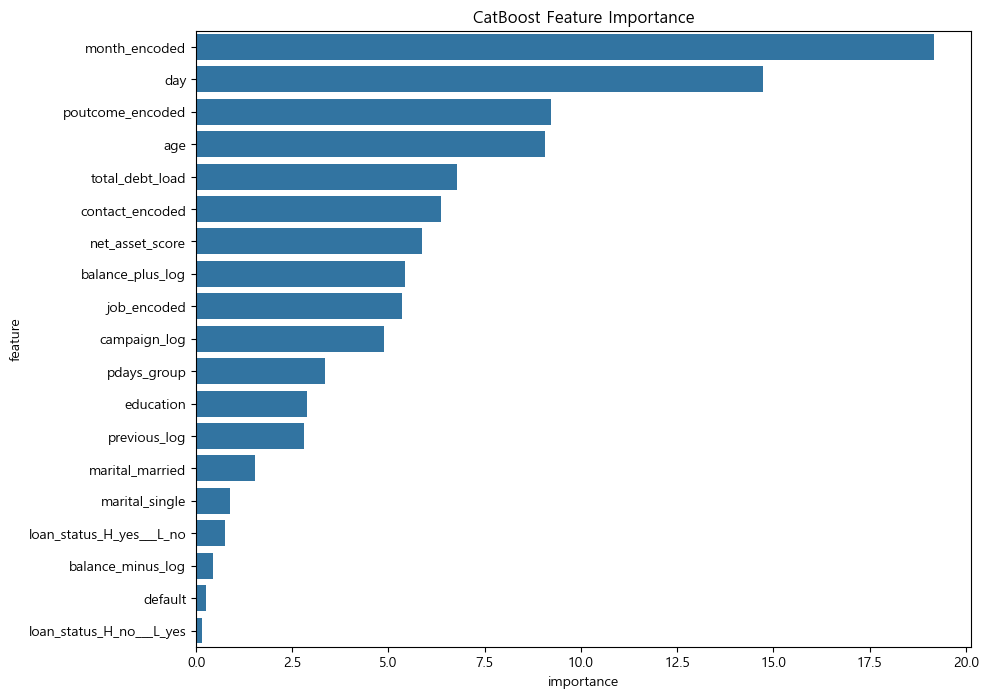

                     feature  importance
11             month_encoded   19.176569
3                        day   14.737997
17          poutcome_encoded    9.225135
0                        age    9.073102
8            total_debt_load    6.789473
18           contact_encoded    6.368155
7            net_asset_score    5.861763
5           balance_plus_log    5.418543
16               job_encoded    5.348536
9               campaign_log    4.894128
4                pdays_group    3.360668
1                  education    2.885259
10              previous_log    2.809182
12           marital_married    1.530454
13            marital_single    0.883152
15  loan_status_H_yes___L_no    0.765006
6          balance_minus_log    0.439162
2                    default    0.267329
14  loan_status_H_no___L_yes    0.166388


In [806]:
# 자동화 버전 - 최적 모델과 스케일러 클래스를 활용하여 간이 학습 및 중요도 시각화
# ✅ best_model, best_scaler_cls를 그대로 사용 → 코드 수정 불필요
if best_scaler_cls:
    best_pipeline = make_pipeline(best_scaler_cls(), best_model)
else:
    best_pipeline = make_pipeline(best_model)

best_pipeline.fit(x_train, y_train)

# 파이프라인에서 모델 스텝 이름을 동적으로 추출 (스케일러 유무와 무관하게 동작)
model_step_name = best_pipeline.steps[-1][0]  # 마지막 스텝 = 모델

importances = pd.DataFrame({
    'feature': x_train.columns,
    'importance': best_pipeline.named_steps[model_step_name].feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importances)
plt.title(f'{best_row["Model"]} Feature Importance')
plt.show()

print(importances)

#### 다중공선성 : VIF

- VIF > 10: 다중공선성이 높음 (주의 필요)
- VIF > 5: 약간의 공선성이 있음

In [807]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF 계산 함수
def check_vif(df):
    vif_df = pd.DataFrame()
    vif_df["feature"] = df.columns
    vif_df["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_df.sort_values(by="VIF", ascending=False)

# 인코딩이 완료된 x_train에 대해 확인
vif_results = check_vif(x_train)
print(vif_results)

                     feature        VIF
16               job_encoded  27.328796
17          poutcome_encoded  19.665161
0                        age  16.214342
18           contact_encoded  15.880867
5           balance_plus_log   9.603156
1                  education   8.027088
9               campaign_log   6.158710
12           marital_married   5.445907
11             month_encoded   5.304159
3                        day   4.502600
13            marital_single   3.955431
10              previous_log   3.879264
4                pdays_group   3.631869
8            total_debt_load   2.246482
15  loan_status_H_yes___L_no   1.953663
7            net_asset_score   1.701173
6          balance_minus_log   1.537014
14  loan_status_H_no___L_yes   1.357641
2                    default   1.078652


#### Feature Importance & VIF 결과 기록

1. age_group 칼럼 삭제 -> age VIF 기존 158.844716 에서 16.408702 으로
2. 

### Optuna

In [811]:
import optuna
from sklearn.metrics import f1_score

def objective(trial):
    # 1. CatBoost 하이퍼파라미터 탐색 범위 설정
    param = {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "random_strength": trial.suggest_float("random_strength", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 2, 30),
        "random_state": 42,
        "verbose": 0,
        "allow_writing_files": False # 불필요한 파일 생성 방지
    }
    
    # 2. 앞서 찾은 최적의 모델(CatBoost) 인스턴스 생성
    model = CatBoostClassifier(**param)
    
    # 3. 앞서 찾은 최적의 스케일러(best_scaler_cls)와 파이프라인 구성
    if best_scaler_cls:
        pipeline = make_pipeline(best_scaler_cls(), model)
    else:
        pipeline = make_pipeline(model)
    
    # 4. 교차 검증(Cross Validation)을 통한 성능 평가
    # 검증 데이터 누수를 막기 위해 pipeline 상태로 CV 수행
    scores = cross_val_score(pipeline, x_train, y_train, scoring="f1_macro", cv=cv, n_jobs=-1)
    
    return scores.mean()

# 5. 튜닝 시작
print(f"🚀 {best_row['Model']} 모델 최적화 시작...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30) 

print("-" * 30)
print(f"🏆 최적의 f1_macro Score: {study.best_value:.4f}")
print("✅ 최적 파라미터:", study.best_params)

[I 2026-04-09 15:21:23,347] A new study created in memory with name: no-name-903a569b-daed-44bd-8dc8-4b97667ad896


🚀 CatBoost 모델 최적화 시작...


[I 2026-04-09 15:21:35,011] Trial 0 finished with value: 0.7236595920770419 and parameters: {'iterations': 1411, 'depth': 5, 'learning_rate': 0.08915535500193102, 'random_strength': 8.224376523834513, 'bagging_temperature': 0.16484762525221763, 'border_count': 220, 'l2_leaf_reg': 30}. Best is trial 0 with value: 0.7236595920770419.
[I 2026-04-09 15:21:54,956] Trial 1 finished with value: 0.7145510235272499 and parameters: {'iterations': 1624, 'depth': 9, 'learning_rate': 0.07467223749074413, 'random_strength': 1.004118641368139, 'bagging_temperature': 0.2800398615472913, 'border_count': 72, 'l2_leaf_reg': 25}. Best is trial 0 with value: 0.7236595920770419.
[I 2026-04-09 15:21:59,779] Trial 2 finished with value: 0.7311368390262092 and parameters: {'iterations': 585, 'depth': 4, 'learning_rate': 0.026930209084603474, 'random_strength': 9.879065837510192, 'bagging_temperature': 0.427504057742797, 'border_count': 48, 'l2_leaf_reg': 9}. Best is trial 2 with value: 0.7311368390262092.
[I 2

------------------------------
🏆 최적의 f1_macro Score: 0.7363
✅ 최적 파라미터: {'iterations': 651, 'depth': 4, 'learning_rate': 0.04359439362510237, 'random_strength': 1.9995414366208686, 'bagging_temperature': 0.8099186250640904, 'border_count': 74, 'l2_leaf_reg': 19}


**모델 선택 근거**
- 목표: 이진 분류 (이탈 여부)
- 선택: Random Forest
- 이유: 피처 중요도 해석이 필요하고, 결측치 처리 후 데이터가 충분함 (n=8,000)
- 제외: Logistic Regression — 비선형 관계가 EDA에서 확인됨 (4.3 참조)

## 결론 / 회고

**결론**
- 핵심 발견 3가지 (수치 포함)
- 분석의 한계 (데이터 기간, 샘플 편향 등)
- 다음에 해볼 것